# NBT small-set preprocessing

This notebook uses the reusable preprocessing pipeline in `src/nbt_pipeline/preprocessing/`.


In [62]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

import matplotlib.pyplot as plt
import pandas as pd

from nbt_pipeline.preprocessing import (
    add_feature_columns,
    blank_like_summary,
    build_preprocessed_dataset,
    cleaning_change_summary,
    clean_dataset,
    column_overview,
    load_nbt_smallset,
    missing_summary,
    time_column_format_summary,
    validate_operation_length_rule,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:.2f}".format)

nbt_smallset_df = load_nbt_smallset()
preprocessed_df = build_preprocessed_dataset()
nbt_smallset_df.head()


,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
0,PLASTIC MINOR 2,11,TH 26 AM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,60mins/day case/LA/ 5mm WLE R abdo scar )(in-situ MM) ....,60.00,00:20:00,00:20:00,00:28:00,00:32:00,09:43:00,00:39:00,00:43:00,19.00,2.00,68.00,1.00,P2,LA (Surgeon),A000012,C4090155,NaN
1,PARKVIEW TH02,11,TH2 (2SD) A Harris (Urology),2.00,M653,Endoscopic resection of prostate NEC,TURP DC GA P3 Xray no Comments = Retention doing ISC....,120.00,00:15:00,00:15:00,00:39:00,00:04:00,NaN,00:47:00,NaN,92.00,1.00,72.00,2.00,P3,LA (Surgeon),C7016369,C7016369,C7042030
2,BRUNEL TH 11,11,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),2.00,Z724,Carpal bone NEC,Right Trapeziectomy +/- LRTI 90 mins....,120.00,00:58:00,00:58:00,00:23:00,00:50:00,15:04:00,00:58:00,NaN,60.00,2.00,70.00,2.00,P4,GA,C7136326,C7136326,7038820
3,PLASTIC MINOR 2,11,TH 26 PM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,60mnins/day case/LA/ excision 4mm margin dorsum left hand direct closure (MM? Adnexal tumour?) c+c dorsum left hand...,60.00,00:12:00,00:12:00,00:22:00,00:30:00,14:47:00,00:40:00,00:47:00,28.00,2.00,85.00,2.00,NaN,LA (Surgeon),A000012,C7040583,NaN
4,BRUNEL TH 15,11,TH15 (3SD) H GILBERT (Urology),2.00,M455,Diagnostic endoscopic examination of bladder using rigid cystoscope,Rigid cystoscopy under GA +/- Biopsy DC GA....,48.00,00:51:00,00:51:00,00:06:00,00:17:00,10:20:00,00:18:00,NaN,27.00,2.00,74.00,3.00,P2,GA,C3015366,C3398948,C3492598


## 1. Load the data


In [63]:
data_path = Path("../data/NBT-SmallSet.xlsx")

nbt_smallset_df = pd.read_excel(data_path, sheet_name="Sheet1")


In [64]:
pd.concat([nbt_smallset_df.head(3), nbt_smallset_df.tail(3)])


,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
0,PLASTIC MINOR 2,11,TH 26 AM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,60mins/day case/LA/ 5mm WLE R abdo scar )(in-situ MM) ....,60.00,00:20:00,00:20:00,00:28:00,00:32:00,09:43:00,00:39:00,00:43:00,19.00,2.00,68.00,1.00,P2,LA (Surgeon),A000012,C4090155,NaN
1,PARKVIEW TH02,11,TH2 (2SD) A Harris (Urology),2.00,M653,Endoscopic resection of prostate NEC,TURP DC GA P3 Xray no Comments = Retention doing ISC....,120.00,00:15:00,00:15:00,00:39:00,00:04:00,NaN,00:47:00,NaN,92.00,1.00,72.00,2.00,P3,LA (Surgeon),C7016369,C7016369,C7042030
2,BRUNEL TH 11,11,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),2.00,Z724,Carpal bone NEC,Right Trapeziectomy +/- LRTI 90 mins....,120.00,00:58:00,00:58:00,00:23:00,00:50:00,15:04:00,00:58:00,NaN,60.00,2.00,70.00,2.00,P4,GA,C7136326,C7136326,7038820
14915,PARKVIEW TH02,11,"TH2 (2SD) S,Bolomytis (Urology)",2.00,M455,Diagnostic endoscopic examination of bladder using rigid cystoscope,m45.5 Cystoscopy and bladder biopsies DC....,60.00,00:48:00,00:48:00,00:45:00,00:54:00,NaN,00:00:00,NaN,72.00,1.00,76.00,3.00,P2,GA,C7477113,C7477113,C3467499
14916,PLASTIC MINOR 1,11,TH25 AM P Consultant (Plastic Surgery),2.00,S069,Unspecified other excision of lesion of skin,90mins/day case/LA/ bcc right nasal dorsum side wall excise and local flap/FTSG staff grade PSOP P2 within 2-...,90.00,00:17:00,00:17:00,00:36:00,00:01:00,10:28:00,00:23:00,00:28:00,66.00,1.00,63.00,2.00,P2,LA (Surgeon),A000012,C6156511,NaN
14917,IR LAB 4,12,IR4 Morning / R Consultant (Radiology),2.00,M131,Percutaneous needle biopsy of lesion of kidney,33mm right lower pole tumour being worked up for cryoablation. For histological confirmation....,45.00,00:00:00,00:00:00,00:23:00,00:32:00,10:41:00,00:33:00,NaN,33.00,1.00,72.00,NaN,P2,LA (Surgeon),A000013,C4717339,NaN


## 2. Data dictionary

This section briefly explains the main columns before preprocessing. Some meanings come from NHS Data Dictionary / NHS England sources, while local operational fields are interpreted from the column names and values in this dataset.

| Column | Brief meaning | Source / note |
|---|---|---|
| `TheatreRoom` | Operating theatre room where the case was planned or performed. | Dataset context; related to operating theatre activity. |
| `admission_type` | Code describing the method/type of admission, for example elective waiting list, booked, planned, or emergency admission. | NHS Data Dictionary: Admission Method. |
| `SessionIDdesc` | Text description of the theatre session, often including theatre number, session timing, consultant, or specialty. | Dataset context; related to NHS operating theatre session concepts. |
| `intended_management` | Planned hospital bed use, for example whether the patient is expected to stay overnight or be treated as a day case. | NHS Data Dictionary: Intended Management. |
| `actual_proc_1_procedure_code` | OPCS-4 code for the main procedure/intervention. | NHS England OPCS-4 classification. |
| `ProcedureDescription` | Text description linked to the main OPCS procedure code. | NHS England OPCS-4 classification. |
| `theatre_notes` | Free-text notes entered for the theatre case, sometimes containing procedure details, duration, anaesthetic notes, or special requirements. | Dataset context/local operational notes. |
| `ExpectedDurationMins` | Planned or expected case duration in minutes. | Dataset context. |
| `into_theatre`, `anaesthetic_start_time`, `incision`, `closure`, `out_of_theatre`, `operation_end_time`, `recovery_time` | Theatre pathway timestamps showing when key stages happened. | Dataset context; used to calculate timings and delays. |
| `operation_length_mins` | Recorded operation duration in minutes. | Dataset context. |
| `sex_national_code` | National code for patient sex/gender category, commonly 1 = male and 2 = female in NHS dictionary coding. | NHS Data Dictionary: Person Stated Gender Code / Person Gender Code. |
| `age_at_operation` | Patient age at the time of operation. | Dataset context. |
| `ASAScore` | ASA physical status score, showing patient fitness/comorbidity risk before anaesthesia. | NHS Data Dictionary: ASA Physical Status Classification System Code. |
| `PriorityLevelCode` | Clinical priority code, such as P2, P3, or P4, indicating urgency/timeframe for elective care. | NHS England elective access policy. |
| `anaesthetic_desc` | Description of anaesthetic type, for example general anaesthetic or local anaesthetic. | Dataset context. |
| `listing_cons_code` | Code for the listing consultant. | Dataset context/local staff code. |
| `theat_surg_1_national_code` | Code for the first theatre surgeon. | Dataset context/local or national staff code. |
| `theat_anae_1_national_code` | Code for the first theatre anaesthetist. | Dataset context/local or national staff code. |


## 3. Basic structure


In [65]:
rows, columns = nbt_smallset_df.shape
print(f"Rows: {rows:,}")
print(f"Columns: {columns:,}")


Rows: 14,918
Columns: 24


In [66]:
column_overview = pd.DataFrame({
    "column": nbt_smallset_df.columns,
    "dtype": nbt_smallset_df.dtypes.astype(str).values,
    "non_null": nbt_smallset_df.notna().sum().values,
    "missing": nbt_smallset_df.isna().sum().values,
    "missing_pct": (nbt_smallset_df.isna().mean() * 100).round(2).values,
    "unique_values": nbt_smallset_df.nunique(dropna=True).values,
})

column_overview.sort_values("missing_pct", ascending=False)


,column,dtype,non_null,missing,missing_pct,unique_values
14,recovery_time,object,1768,13150,88.15,60
19,PriorityLevelCode,str,6355,8563,57.40,4
23,theat_anae_1_national_code,object,9512,5406,36.24,323
18,ASAScore,float64,13664,1254,8.41,7
20,anaesthetic_desc,str,14174,744,4.99,7
12,out_of_theatre,object,14321,597,4.00,1193
7,ExpectedDurationMins,float64,14704,214,1.43,189
22,theat_surg_1_national_code,object,14803,115,0.77,390
4,actual_proc_1_procedure_code,str,14828,90,0.60,1038
5,ProcedureDescription,str,14828,90,0.60,1038


### How to read this table

This table gives a quick health check for every column in the dataset.

- `non_null`: how many rows have a real value in that column.
- `missing`: how many rows are empty in that column.
- `missing_pct`: the percentage of rows that are empty. A high value means the column may be less useful or needs cleaning.
- `unique_values`: how many different values appear in that column. This helps us understand whether the column is categorical, repeated, or very detailed.

For example, if a column has high `missing_pct`, we should be careful using it. If it has only a few `unique_values`, it may be useful for grouping or modelling as a category.
\n


In [67]:
nbt_smallset_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 14918 entries, 0 to 14917
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   TheatreRoom                   14918 non-null  str    
 1   admission_type                14916 non-null  object 
 2   SessionIDdesc                 14918 non-null  str    
 3   intended_management           14913 non-null  float64
 4   actual_proc_1_procedure_code  14828 non-null  str    
 5   ProcedureDescription          14828 non-null  str    
 6   theatre_notes                 14842 non-null  str    
 7   ExpectedDurationMins          14704 non-null  float64
 8   into_theatre                  14918 non-null  object 
 9   anaesthetic_start_time        14918 non-null  object 
 10  incision                      14862 non-null  object 
 11  closure                       14845 non-null  object 
 12  out_of_theatre                14321 non-null  object 
 13  operation_en

## 4. Data quality checks


### 4.1 Missing values

This check counts NaN / missing values for every column and calculates the percentage missing. It helps identify columns that may need cleaning or may be too incomplete to use safely.


In [68]:
basic_missing_df = (
    nbt_smallset_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)
basic_missing_df["missing_pct"] = (basic_missing_df["missing_count"] / len(nbt_smallset_df) * 100).round(2)
basic_missing_df.sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
recovery_time,13150,88.15
PriorityLevelCode,8563,57.40
theat_anae_1_national_code,5406,36.24
ASAScore,1254,8.41
anaesthetic_desc,744,4.99
out_of_theatre,597,4.00
ExpectedDurationMins,214,1.43
theat_surg_1_national_code,115,0.77
actual_proc_1_procedure_code,90,0.60
ProcedureDescription,90,0.60


**Result interpretation:** Columns at the top have the most missing values. A high `missing_pct` means we should be careful using that column because many rows do not contain information. Low or zero `missing_pct` means the column is more complete.


### 4.2 Duplicate rows

This check looks for full rows that are repeated exactly. Duplicate rows should be reviewed because they can bias counts, summaries, and models if the same case is accidentally included more than once.


In [69]:
duplicate_count = nbt_smallset_df.duplicated().sum()
print(f"Exact duplicate rows: {duplicate_count:,}")

nbt_smallset_df[nbt_smallset_df.duplicated(keep=False)].sort_values(nbt_smallset_df.columns.tolist()).head(20)


Exact duplicate rows: 6


,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
5305,CATH LAB 05,24,C Consultant (Cardiology) Elective & Emergency,1.00,K636,Coronary arteriography NEC,83 Direct admission from Echo department with Decompensated HF secondary to severe AS Bilateral Pleural effusion...,54.00,00:35:00,00:35:00,00:51:00,00:06:00,17:29:00,00:13:00,NaN,38.00,1.00,83.00,NaN,NaN,LA (Surgeon),C3289073,A000003,NaN
5382,CATH LAB 05,24,C Consultant (Cardiology) Elective & Emergency,1.00,K636,Coronary arteriography NEC,83 Direct admission from Echo department with Decompensated HF secondary to severe AS Bilateral Pleural effusion...,54.00,00:35:00,00:35:00,00:51:00,00:06:00,17:29:00,00:13:00,NaN,38.00,1.00,83.00,NaN,NaN,LA (Surgeon),C3289073,A000003,NaN
4960,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"11:30- P2, Excision biopsy lesion ?MM left back, LA/DC....",60.00,00:54:00,00:54:00,00:01:00,00:10:00,11:13:00,00:11:00,00:13:00,17.00,2.00,31.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
5002,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"11:30- P2, Excision biopsy lesion ?MM left back, LA/DC....",60.00,00:54:00,00:54:00,00:01:00,00:10:00,11:13:00,00:11:00,00:13:00,17.00,2.00,31.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
12096,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"15:30 - P2, Excision ?Haemangioma ?Bcc ?Amelanotic MM and direct closure leftupper forehead, LA/DC....",60.00,00:29:00,00:29:00,00:29:00,00:55:00,17:00:00,00:55:00,NaN,26.00,2.00,63.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
12116,PLASTIC MINOR 2,11,P Consultant (Plastic Surgery),2.00,NaN,NaN,"15:30 - P2, Excision ?Haemangioma ?Bcc ?Amelanotic MM and direct closure leftupper forehead, LA/DC....",60.00,00:29:00,00:29:00,00:29:00,00:55:00,17:00:00,00:55:00,NaN,26.00,2.00,63.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
4967,PLASTIC MINOR 2,11,TH26 (2SD) P Consultant (Plastic Surgery),2.00,NaN,NaN,"08:30 - Excision ?MM left forarm, LA/DC....",30.00,00:39:00,00:39:00,00:39:00,00:39:00,09:39:00,00:39:00,00:40:00,0.00,2.00,73.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
5045,PLASTIC MINOR 2,11,TH26 (2SD) P Consultant (Plastic Surgery),2.00,NaN,NaN,"08:30 - Excision ?MM left forarm, LA/DC....",30.00,00:39:00,00:39:00,00:39:00,00:39:00,09:39:00,00:39:00,00:40:00,0.00,2.00,73.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
10056,PLASTIC MINOR 2,11,TH26 2SD KPI P Consultant (Plastic Surgery),2.00,NaN,NaN,Excision ?SCC left forearm 30 minutes LA....,30.00,00:15:00,00:15:00,00:18:00,00:38:00,15:46:00,00:40:00,00:46:00,25.00,2.00,85.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN
10152,PLASTIC MINOR 2,11,TH26 2SD KPI P Consultant (Plastic Surgery),2.00,NaN,NaN,Excision ?SCC left forearm 30 minutes LA....,30.00,00:15:00,00:15:00,00:18:00,00:38:00,15:46:00,00:40:00,00:46:00,25.00,2.00,85.00,NaN,NaN,LA (Surgeon),A000012,C6053636,NaN


**Result interpretation:** The printed number shows how many full rows are exact duplicates. If this number is greater than zero, the displayed rows should be reviewed before removing them, because some repeats may be real repeated cases and some may be accidental duplicates.


### 4.3 Blank-like text values

This check looks for text values that are not true NaN but still behave like missing information, such as empty strings or single dots. These values may need to be converted to missing values during cleaning.


In [70]:
text_columns = nbt_smallset_df.select_dtypes(include="object").columns

blank_like_summary = []
for column in text_columns:
    cleaned = nbt_smallset_df[column].astype("string").str.strip()
    blank_like_summary.append({
        "column": column,
        "empty_strings": (cleaned == "").sum(),
        "single_dots": (cleaned == ".").sum(),
        "unique_values": cleaned.nunique(dropna=True),
    })

pd.DataFrame(blank_like_summary).sort_values(["single_dots", "empty_strings"], ascending=False)


C:\Users\Alaa\AppData\Local\Temp\ipykernel_21904\2297323768.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = nbt_smallset_df.select_dtypes(include="object").columns


,column,empty_strings,single_dots,unique_values
5,theatre_notes,0,2488,9765
0,TheatreRoom,0,0,45
1,admission_type,0,0,16
2,SessionIDdesc,0,0,2281
3,actual_proc_1_procedure_code,0,0,1038
4,ProcedureDescription,0,0,1038
6,into_theatre,0,0,69
7,anaesthetic_start_time,0,0,69
8,incision,0,0,67
9,closure,0,0,69


**Result interpretation:** This output checks only text columns. High `empty_strings` or `single_dots` means the column contains values that look like missing information but are not stored as real `NaN`. These should usually be cleaned later in the preprocessing pipeline.


## 5. Numeric variable inspection


Before inspecting variables, it is important to use the meaning of the column, not only the pandas data type. Some columns are stored as numbers but actually represent categories or codes. For example, ASAScore, sex_national_code, admission_type, and intended_management are coded variables, so they are inspected in the categorical/coded section rather than using numeric averages.


### 5.1 Summary statistics

This table summarises the true numeric measurement columns using count, mean, standard deviation, minimum, quartiles, and maximum. These checks are useful for continuous measurements such as planned duration, actual operation length, and patient age.


In [71]:
numeric_columns = [
    "ExpectedDurationMins",
    "operation_length_mins",
    "age_at_operation",
]

nbt_smallset_df[numeric_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
ExpectedDurationMins,14704.00,98.28,88.53,0.00,60.00,60.00,120.00,1415.00
operation_length_mins,14845.00,97.89,92.50,0.00,39.00,70.00,124.00,1017.00
age_at_operation,14872.00,57.07,19.59,16.00,40.00,59.00,73.00,107.00


**Result interpretation:** This output shows the general range of true numeric variables. ExpectedDurationMins and operation_length_mins help compare planned and actual theatre time. age_at_operation helps describe the patient population and identify suspicious age values.


### 5.2 Suspicious numeric values

This check counts values that may be impossible or suspicious for true numeric columns, such as zero duration, age equal to zero, negative age, or age above 125.


In [72]:
numeric_quality_checks = pd.DataFrame({
    "zero_expected_duration": [(nbt_smallset_df["ExpectedDurationMins"] == 0).sum()],
    "zero_operation_length": [(nbt_smallset_df["operation_length_mins"] == 0).sum()],
    "age_zero": [(nbt_smallset_df["age_at_operation"] == 0).sum()],
    "age_negative": [(nbt_smallset_df["age_at_operation"] < 0).sum()],
    "age_over_125": [(nbt_smallset_df["age_at_operation"] > 125).sum()],
})

numeric_quality_checks.T.rename(columns={0: "row_count"})


,row_count
zero_expected_duration,62
zero_operation_length,9
age_zero,0
age_negative,0
age_over_125,0


**Result interpretation:** The result shows whether duration and age contain suspicious values. Zero durations should be reviewed because they may indicate missing or incorrectly recorded timings. Age values equal to zero, negative, or above 125 would also need review.


### 5.3 Planned versus actual duration in minutes

This creates duration_error_mins, which compares the recorded operation length with the expected duration. Positive values mean the case took longer than planned; negative values mean it finished faster than planned. Median is included because duration data often has outliers, so the median can describe the typical case better than the mean.


In [73]:
duration_df = nbt_smallset_df.copy()
duration_df["duration_error_mins"] = duration_df["operation_length_mins"] - duration_df["ExpectedDurationMins"]

duration_summary = duration_df[["ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max",
]).T

duration_summary


,count,mean,median,std,min,max
ExpectedDurationMins,14704.00,98.28,60.00,88.53,0.00,1415.00
operation_length_mins,14845.00,97.89,70.00,92.50,0.00,1017.00
duration_error_mins,14632.00,-0.15,-8.00,69.13,-1399.00,970.00


**Result interpretation:** duration_error_mins compares actual operation length with expected duration. Positive values mean the operation took longer than planned; negative values mean it was shorter. In this dataset, the median expected duration is 60 minutes and the median actual operation length is 70 minutes. The median duration error is -8 minutes, meaning the typical recorded case finished slightly faster than planned. The mean duration error is close to zero, so overall planning and actual duration are similar on average. However, the minimum and maximum duration errors are very large, which suggests there are extreme outliers that should be reviewed before modelling.


### 5.4 Largest duration overruns

This table shows the operations with the biggest positive duration_error_mins. In simple words, these are the cases where the actual operation length was much longer than the expected duration.

Formula: duration_error_mins = operation_length_mins - ExpectedDurationMins


In [74]:
duration_df[
    ["TheatreRoom", "ProcedureDescription", "ExpectedDurationMins", "operation_length_mins", "duration_error_mins"]
].sort_values("duration_error_mins", ascending=False).head(10)


,TheatreRoom,ProcedureDescription,ExpectedDurationMins,operation_length_mins,duration_error_mins
5582,IR LAB 3,Open embolectomy of cerebral artery,0.00,970.00,970.00
8103,BRUNEL TH 06,Unspecified opening of cranium,150.00,1017.00,867.00
9121,BRUNEL TH 07,Posterior fusion of joint of cervical spine NEC,180.00,971.00,791.00
8273,GYNAE TH 01,Elective lower uterine segment caesarean delivery,60.00,790.00,730.00
2317,BRUNEL TH 06,Other specified extirpation of lesion of meninges of brain,150.00,779.00,629.00
6969,BRUNEL TH 01,Debridement of burnt skin of head or neck,60.00,680.00,620.00
9522,BRUNEL TH 04,Shaft of tibia NEC,90.00,655.00,565.00
13037,BRUNEL TH 04,Left sided operation,60.00,586.00,526.00
13448,BRUNEL TH 09,Primary total prosthetic replacement of hip joint using cement,120.00,642.00,522.00
13504,BRUNEL TH 09,Primary total prosthetic replacement of hip joint using cement,120.00,642.00,522.00


**Result interpretation:** The rows at the top are the largest overruns. For example, if ExpectedDurationMins is 60 and operation_length_mins is 200, the duration_error_mins is 140, meaning the case took 140 minutes longer than planned. These rows should be reviewed because they may be true complex operations, underestimated planned durations, or possible data quality problems. They are not automatically wrong, but they are important to inspect before modelling.


## 6. Categorical and coded variable inspection


### 6.1 Categorical overview

This table checks categorical and coded columns using unique values, missing counts, and missing percentages. It helps identify columns with many categories, such as procedure descriptions, and columns with high missingness, such as priority level or anaesthetist code.


In [75]:
categorical_columns = [
    "TheatreRoom",
    "admission_type",
    "intended_management",
    "sex_national_code",
    "ASAScore",
    "SessionIDdesc",
    "actual_proc_1_procedure_code",
    "ProcedureDescription",
    "PriorityLevelCode",
    "anaesthetic_desc",
    "listing_cons_code",
    "theat_surg_1_national_code",
    "theat_anae_1_national_code",
]

pd.DataFrame({
    "unique_values": nbt_smallset_df[categorical_columns].nunique(dropna=True),
    "missing_count": nbt_smallset_df[categorical_columns].isna().sum(),
    "missing_pct": (nbt_smallset_df[categorical_columns].isna().mean() * 100).round(2),
}).sort_values("unique_values", ascending=False)


,unique_values,missing_count,missing_pct
SessionIDdesc,2288,0,0.00
actual_proc_1_procedure_code,1038,90,0.60
ProcedureDescription,1038,90,0.60
theat_surg_1_national_code,390,115,0.77
theat_anae_1_national_code,323,5406,36.24
listing_cons_code,283,77,0.52
TheatreRoom,45,0,0.00
admission_type,16,2,0.01
ASAScore,7,1254,8.41
anaesthetic_desc,7,744,4.99


**Result interpretation:** SessionIDdesc has many unique values, so it contains detailed free-text session information rather than a small set of categories. ProcedureDescription and actual_proc_1_procedure_code also have many unique values, which means procedure type is detailed and may need grouping later. PriorityLevelCode has high missingness, so it should be used carefully. TheatreRoom has no missing values and a manageable number of categories, so it is useful for grouping and analysis.


### 6.2 Coded categorical variables

Some columns look numeric but are actually categories or ordered codes. For these columns, value counts are more useful than mean or standard deviation.


### 6.2.1 Meaning of key coded variables

The table below explains the main coded variables used in this dataset. These meanings are based on NHS Data Dictionary / NHS England sources where available, with project labels used to keep the codes readable.

| Column | Codes / meaning |
|---|---|
| admission_type | 11 = elective waiting list; 12 = elective booked; 13 = elective planned; 21-25 and 2A-2D = emergency admission routes; 31-32 = maternity admission; 81-83 = other admission/transfer/birth routes; 98 = not applicable. |
| intended_management | 1 = inpatient; 2 = day case; 3 = regular day attender; 4 = regular night attender; 5 = mother and baby; 8 = not applicable; 9 = not known. |
| sex_national_code | 1 = male; 2 = female. Other NHS dictionary versions may also include 9 or X for indeterminate/not known, but this dataset mainly contains 1 and 2. |
| ASAScore | 1-6 ASA physical status category. 1 is healthiest; higher values mean greater physical/anaesthetic risk; 6 is brain-dead organ donor. |
| PriorityLevelCode | P1 = highest/most urgent priority; P2 = high priority; P3 = medium priority; P4 = routine or lower priority. |

These columns should be analysed using counts and validity checks, not numeric averages.

Detailed source entries for these code meanings are listed in the References section at the end of the notebook.


### 6.2.2 Code frequency counts

This code counts how often each code or category appears in the selected coded variables. This is better than calculating averages because these values represent groups, not continuous measurements.


In [76]:
coded_category_columns = [
    "admission_type",
    "intended_management",
    "sex_national_code",
    "ASAScore",
    "PriorityLevelCode",
]

for column in coded_category_columns:
    print(f"Top values for {column}")
    display(nbt_smallset_df[column].value_counts(dropna=False).head(10).to_frame("count"))


Top values for admission_type


,count
admission_type,
11,7780
21,2480
12,1592
13,975
31,714
22,438
2D,281
2A,267
24,233


Top values for intended_management


,count
intended_management,
1.00,7599
2.00,7108
8.00,169
3.00,31
5.00,5
NaN,5
4.00,1


Top values for sex_national_code


,count
sex_national_code,
2.00,7825
1.00,7047
NaN,46


Top values for ASAScore


,count
ASAScore,
2.00,6219
3.00,4241
1.00,2424
NaN,1254
4.00,723
5.00,35
6.00,21
0.00,1


Top values for PriorityLevelCode


,count
PriorityLevelCode,
NaN,8563
P2,3714
P3,1521
P4,1119
P1,1


**Result interpretation:** The coded counts show the most common codes in each variable. admission_type is mostly code 11, intended_management is mainly split between codes 1 and 2, sex_national_code has two main categories, ASAScore is mostly 1, 2, or 3, and PriorityLevelCode is mostly missing followed by P2, P3, and P4. These should be interpreted as categories, not averaged as numbers.


### 6.2.3 Main procedure code inspection

`actual_proc_1_procedure_code` is a coded categorical column. It contains the main OPCS procedure code for the operation. Even though the codes contain numbers, they are not measurements, so we inspect them using missing values, unique counts, and frequency counts.

This is useful because procedure type is likely to affect operation duration, theatre use, and later modelling.


In [77]:
procedure_code_summary = pd.DataFrame(
    {
        "column": ["actual_proc_1_procedure_code"],
        "missing_count": [nbt_smallset_df["actual_proc_1_procedure_code"].isna().sum()],
        "missing_pct": [(nbt_smallset_df["actual_proc_1_procedure_code"].isna().mean() * 100).round(2)],
        "unique_values": [nbt_smallset_df["actual_proc_1_procedure_code"].nunique(dropna=True)],
    }
)

procedure_code_summary


,column,missing_count,missing_pct,unique_values
0,actual_proc_1_procedure_code,90,0.60,1038


The next table shows the most common procedure codes together with their procedure descriptions. This is easier to interpret than looking at the code alone.


In [78]:
top_procedure_codes = (
    nbt_smallset_df[
        ["actual_proc_1_procedure_code", "ProcedureDescription"]
    ]
    .value_counts(dropna=False)
    .head(20)
    .reset_index(name="count")
)

top_procedure_codes


,actual_proc_1_procedure_code,ProcedureDescription,count
0,S069,Unspecified other excision of lesion of skin,1423
1,R172,Elective lower uterine segment caesarean delivery,633
2,Y808,Other specified general anaesthetic,326
3,K636,Coronary arteriography NEC,278
4,R182,Lower uterine segment caesarean delivery NEC,259
5,M162,Maintenance of drainage tube of kidney,223
6,S571,Debridement of skin NEC,215
7,J183,Total cholecystectomy NEC,181
8,L711,Percutaneous transluminal angioplasty of artery,178
9,M611,Total excision of prostate and capsule of prostate,173


This final check looks for procedure codes that appear with more than one description. A code may have several descriptions because of spelling, punctuation, or local wording differences. These are not automatically wrong, but they should be reviewed before grouping procedures.


In [79]:
procedure_description_consistency = (
    nbt_smallset_df
    .dropna(subset=["actual_proc_1_procedure_code"])
    .groupby("actual_proc_1_procedure_code")["ProcedureDescription"]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .to_frame("unique_descriptions")
)

procedure_description_consistency.head(20)


,unique_descriptions
actual_proc_1_procedure_code,
A012,1
A021,1
A022,1
A023,1
A024,1
A025,1
A028,1
A042,1
A051,1


This check focuses only on rows where `actual_proc_1_procedure_code` is missing. It tests whether `ProcedureDescription` is available in those rows and could be used to recover the missing code.


In [80]:
missing_procedure_code = nbt_smallset_df["actual_proc_1_procedure_code"].isna()

procedure_missing_recovery_check = pd.DataFrame(
    {
        "missing_procedure_code_rows": [missing_procedure_code.sum()],
        "procedure_description_missing": [
            nbt_smallset_df.loc[missing_procedure_code, "ProcedureDescription"].isna().sum()
        ],
        "procedure_description_present": [
            nbt_smallset_df.loc[missing_procedure_code, "ProcedureDescription"].notna().sum()
        ],
    }
)

procedure_missing_recovery_check


,missing_procedure_code_rows,procedure_description_missing,procedure_description_present
0,90,90,0


In [81]:
nbt_smallset_df.loc[
    missing_procedure_code,
    ["actual_proc_1_procedure_code", "ProcedureDescription"],
].value_counts(dropna=False).reset_index(name="count")


,actual_proc_1_procedure_code,ProcedureDescription,count
0,NaN,NaN,90


**Result interpretation:** If `procedure_description_present` is 0, the missing procedure codes cannot be filled from `ProcedureDescription`, because the description is missing in the same rows. These rows should remain missing unless another reliable source column is found later.


**Result interpretation:** This inspection tells us how detailed the procedure coding is. If there are many unique procedure codes, we may need grouping later before modelling. The top procedure-code table shows the most common operations in the dataset, while the consistency check highlights codes whose descriptions may need standardisation.


### 6.2.4 Staff code inspection

`listing_cons_code`, `theat_surg_1_national_code`, and `theat_anae_1_national_code` are staff/code identifier columns. They should be treated as categorical IDs, not numeric variables.

This inspection checks how complete they are and how many different staff codes appear. This matters because high-cardinality staff codes can be useful for workload analysis, but they may be difficult to use directly in modelling.


In [82]:
staff_code_columns = [
    "listing_cons_code",
    "theat_surg_1_national_code",
    "theat_anae_1_national_code",
]

staff_code_summary = pd.DataFrame(
    {
        "unique_values": nbt_smallset_df[staff_code_columns].nunique(dropna=True),
        "missing_count": nbt_smallset_df[staff_code_columns].isna().sum(),
        "missing_pct": (nbt_smallset_df[staff_code_columns].isna().mean() * 100).round(2),
    }
).sort_values("missing_pct", ascending=False)

staff_code_summary


,unique_values,missing_count,missing_pct
theat_anae_1_national_code,323,5406,36.24
theat_surg_1_national_code,390,115,0.77
listing_cons_code,283,77,0.52


The next output shows the most common values in each staff-code column. This is useful for identifying whether a small number of staff codes dominate the dataset or whether cases are spread across many codes.


In [83]:
for column in staff_code_columns:
    print(f"Top values for {column}")
    display(nbt_smallset_df[column].value_counts(dropna=False).head(10).to_frame("count"))


Top values for listing_cons_code


,count
listing_cons_code,
A000012,2172
A000013,1949
A000001,1405
A000010,878
A000015,728
A000003,205
C3015366,136
C3613441,107
A000018,103


Top values for theat_surg_1_national_code


,count
theat_surg_1_national_code,
C3325111,451
C4406129,390
C6053636,285
X000001,283
C6102738,277
C6106690,264
C4717339,223
A000003,204
C6156511,181


Top values for theat_anae_1_national_code


,count
theat_anae_1_national_code,
NaN,5406
walt03s,199
C3549672,148
4693819,148
C3486959,146
C6050872,130
C4306913,127
NB01049,127
C4018748,123


**Result interpretation:** The three staff-code columns are categorical identifiers, not numeric values. `listing_cons_code` has 283 unique values and only 77 missing rows (0.52%), so the listing consultant is recorded for almost all cases. `theat_surg_1_national_code` has 390 unique values and 115 missing rows (0.77%), so the main surgeon code is also mostly complete. `theat_anae_1_national_code` has 323 unique values, but 5,406 missing rows (36.24%), which means the anaesthetist code is much less complete and should be used carefully.

Overall, these columns may be useful for workload analysis and possible team-level patterns. However, they contain many unique staff identifiers, so they should not be treated as simple low-cardinality categories. For later modelling, they may need to be grouped, anonymised, or excluded to avoid too many small groups and to reduce privacy or fairness concerns.


### 6.3 Coded category validity checks

For coded variables, we check whether the recorded codes fall inside the expected code lists. This is different from calculating averages. It helps find unexpected codes that may need recoding, investigation, or conversion to missing values.


In [84]:
from nbt_pipeline.preprocessing.codes import coded_value_quality

coded_value_quality(nbt_smallset_df)


,column,missing_count,invalid_count,invalid_values,valid_values
0,admission_type,2,0,,"11, 12, 13, 21, 22, 23, 24, 25, 2A, 2B, 2C, 2D, 31, 32, 81, 82, 83, 98"
1,intended_management,5,0,,"1, 2, 3, 4, 5, 8, 9"
2,sex_national_code,46,0,,"1, 2"
3,ASAScore,1254,1,0,"1, 2, 3, 4, 5, 6"
4,PriorityLevelCode,8563,0,,"P1, P2, P3, P4"


**Result interpretation:** This table shows missing and unexpected values for the main coded columns. `invalid_count` means the value is present but not in the expected code list. For example, ASA should usually be between 1 and 6, priority should be P1 to P4, and admission/intended-management codes should match the NHS-style code lists used in this project. Any invalid values should be reviewed before modelling.


### 6.4 Most common text categories

This output shows the most frequent values for selected text columns. It helps identify the busiest theatre rooms, most common procedures, and most common anaesthetic descriptions.


In [85]:
for column in ["TheatreRoom", "ProcedureDescription", "anaesthetic_desc"]:
    print(f"Top values for {column}")
    display(nbt_smallset_df[column].value_counts(dropna=False).head(10).to_frame("count"))


Top values for TheatreRoom


,count
TheatreRoom,
BRUNEL TH 05,706
PLASTIC MINOR 1,651
IR LAB 1,631
GYNAE TH 02,621
IR LAB 2,551
CATH LAB 05,524
PLASTIC MINOR 2,523
BRUNEL TH 03,520
BRUNEL TH 06,516


Top values for ProcedureDescription


,count
ProcedureDescription,
Unspecified other excision of lesion of skin,1423
Elective lower uterine segment caesarean delivery,633
Other specified general anaesthetic,326
Coronary arteriography NEC,278
Lower uterine segment caesarean delivery NEC,259
Maintenance of drainage tube of kidney,223
Debridement of skin NEC,215
Total cholecystectomy NEC,181
Percutaneous transluminal angioplasty of artery,178


Top values for anaesthetic_desc


,count
anaesthetic_desc,
GA,8192
LA (Surgeon),4113
NaN,744
Neuraxial Block,655
No Anaesthetic,460
Sedation,307
GA and Regional,307
Regional Only,140


**Result interpretation:** These counts are useful for understanding the main patterns in the dataset. Very common theatre rooms or procedures may strongly influence later analysis. Rare categories may need grouping before modelling so the model is not trained on too many tiny groups.


## 7. Session description feature extraction

`SessionIDdesc` contains several useful pieces of information inside one text column. We extract these using regular expressions in the reusable preprocessing pipeline, not manually in the notebook.

The new columns show:

| New column | What it shows | Example |
|---|---|---|
| `session_theatre_code` | The theatre or session code at the start of the text. | `TH26`, `TH2`, `IR1` |
| `session_code_prefix` | The letter prefix from the session code. | `TH`, `TTH`, `IR`, `CT` |
| `session_list_type` | The list/session marker written in the description. This may show the type of theatre list. | `AM`, `PM`, `EVE`, `2SD`, `3SD`, `PM/EVE` |
| `session_time_band` | A simpler time group extracted from the text. | `AM`, `PM`, `EVE` |
| `session_consultant` | The consultant or list holder name/text after removing theatre code, list marker, and specialty. | `A Harris`, `Mr A Kiszely`, `P Consultant` |
| `session_specialty` | The clinical specialty normalised into a cleaner label. | `Urology`, `Plastic surgery`, `T&O` |

This step is useful because it turns one messy text column into structured columns that can be used for grouping, analysis, and modelling.


In [86]:
from importlib import reload

from nbt_pipeline.preprocessing import build_preprocessed_dataset
import nbt_pipeline.preprocessing.session as session_module
import nbt_pipeline.preprocessing.specialty as specialty_module

reload(session_module)
reload(specialty_module)

if "preprocessed_df" not in globals():
    preprocessed_df = build_preprocessed_dataset()

session_df = session_module.add_session_description_features(preprocessed_df)
session_df = specialty_module.add_specialty_column(session_df)

session_feature_columns = [
    "SessionIDdesc",
    "session_theatre_code",
    "session_code_prefix",
    "session_list_type",
    "session_time_band",
    "session_consultant",
    "session_specialty",
]

session_df[session_feature_columns].head(15)


,SessionIDdesc,session_theatre_code,session_code_prefix,session_list_type,session_time_band,session_consultant,session_specialty
0,TH 26 AM P Consultant (Plastic Surgery),TH26,TH,AM,AM,P Consultant,Plastic surgery
1,TH2 (2SD) A Harris (Urology),TH2,TH,2SD,NaN,A Harris,Urology
2,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),TH11,TH,2SD,NaN,Mr A Kiszely,T&O
3,TH 26 PM P Consultant (Plastic Surgery),TH26,TH,PM,PM,P Consultant,Plastic surgery
4,TH15 (3SD) H GILBERT (Urology),TH15,TH,3SD,NaN,H GILBERT,Urology
5,TH23 (3SD) Mr J Murray (Trauma and Orthopaedics),TH23,TH,3SD,NaN,Mr J Murray,T&O
6,IR1 Morning / R Consultant (Radiology),IR1,IR,AM,AM,R Consultant,Radiology
7,TH11 (EVE) Mr T Chapman (Plastic Surgery),TH11,TH,EVE,EVE,Mr T Chapman,Plastic surgery
8,TH 2 (2SD) P Consultant (Plastic Surgery),TH2,TH,2SD,NaN,P Consultant,Plastic surgery
9,TH12 (2SD) F.Boriani (Plastic Surgery),TH12,TH,2SD,NaN,F.Boriani,Plastic surgery


**Result interpretation:** Each row keeps the original `SessionIDdesc`, then shows the structured values extracted from it. Empty values mean that part was not clearly present in the text. These fields should be checked on samples before using them for final modelling.


### 7.1 Quality check for extracted session columns

After creating new columns from `SessionIDdesc`, we check them again. This tells us which extracted features are complete enough to trust and which ones have many missing values.


In [87]:
from importlib import reload

import nbt_pipeline.preprocessing.session as session_module
import nbt_pipeline.preprocessing.specialty as specialty_module

reload(session_module)
reload(specialty_module)

if "preprocessed_df" not in globals():
    preprocessed_df = build_preprocessed_dataset()

session_df = session_module.add_session_description_features(preprocessed_df)
session_df = specialty_module.add_specialty_column(session_df)

session_extracted_columns = [
    "session_theatre_code",
    "session_code_prefix",
    "session_list_type",
    "session_time_band",
    "session_consultant",
    "session_specialty",
]

pd.DataFrame(
    {
        "column": session_extracted_columns,
        "non_null": [session_df[column].notna().sum() for column in session_extracted_columns],
        "missing": [session_df[column].isna().sum() for column in session_extracted_columns],
        "missing_pct": [session_df[column].isna().mean() * 100 for column in session_extracted_columns],
        "unique_values": [session_df[column].nunique(dropna=True) for column in session_extracted_columns],
    }
)


,column,non_null,missing,missing_pct,unique_values
0,session_theatre_code,13806,1112,7.45,36
1,session_code_prefix,13806,1112,7.45,4
2,session_list_type,11601,3317,22.23,6
3,session_time_band,4915,10003,67.05,3
4,session_consultant,14911,7,0.05,552
5,session_specialty,14918,0,0.00,269


**Result interpretation:** If an extracted column has a high `missing_pct`, the pattern was not present in many `SessionIDdesc` values. That does not always mean the extraction is wrong; it may mean that information is not recorded consistently. Columns with low missingness are stronger candidates for later analysis or modelling.


### 7.2 Comparing session consultant with staff codes

`session_consultant` is extracted from the text in `SessionIDdesc`, while `listing_cons_code`, `theat_surg_1_national_code`, and `theat_anae_1_national_code` are coded staff identifiers from the dataset.

This check does not prove that the columns identify the same person, because one column contains names/text and the others contain codes. However, it helps inspect whether the extracted consultant text is related to the staff-code fields and whether it may duplicate information already present elsewhere.


In [88]:
staff_code_columns = [
    "listing_cons_code",
    "theat_surg_1_national_code",
    "theat_anae_1_national_code",
]

session_staff_mapping = (
    session_df
    .dropna(subset=["session_consultant"])
    .groupby("session_consultant")
    .agg(
        row_count=("SessionIDdesc", "size"),
        unique_listing_cons_codes=("listing_cons_code", lambda s: s.dropna().nunique()),
        unique_surgeon_codes=("theat_surg_1_national_code", lambda s: s.dropna().nunique()),
        unique_anaesthetist_codes=("theat_anae_1_national_code", lambda s: s.dropna().nunique()),
    )
    .reset_index()
    .sort_values("row_count", ascending=False)
)

session_staff_mapping.head(20)


,session_consultant,row_count,unique_listing_cons_codes,unique_surgeon_codes,unique_anaesthetist_codes
443,P Consultant,2127,27,77,121
468,R Consultant,1536,10,148,89
38,A Consultant,1356,21,181,190
521,T Consultant,824,22,58,117
436,O Consultant,692,11,34,86
102,C Consultant Elective &,660,12,41,2
164,ELECTIVE O Consultant,363,19,10,56
470,R Consultant Emergeny,224,1,75,17
93,All Day / R Consultant,133,2,68,48
111,C Wong,106,1,10,30


The next table focuses on consultant text values that map to multiple staff codes. These are the cases most worth reviewing because they may represent team labels, generic labels, spelling variation, or real differences between list holder, listing consultant, and operating surgeon.


In [89]:
session_staff_many_mappings = session_staff_mapping[
    (session_staff_mapping["row_count"] >= 5)
    & (
        (session_staff_mapping["unique_listing_cons_codes"] > 1)
        | (session_staff_mapping["unique_surgeon_codes"] > 1)
        | (session_staff_mapping["unique_anaesthetist_codes"] > 1)
    )
].sort_values(
    ["unique_surgeon_codes", "unique_listing_cons_codes", "row_count"],
    ascending=False,
)

session_staff_many_mappings.head(20)


,session_consultant,row_count,unique_listing_cons_codes,unique_surgeon_codes,unique_anaesthetist_codes
38,A Consultant,1356,21,181,190
468,R Consultant,1536,10,148,89
443,P Consultant,2127,27,77,121
470,R Consultant Emergeny,224,1,75,17
93,All Day / R Consultant,133,2,68,48
521,T Consultant,824,22,58,117
102,C Consultant Elective &,660,12,41,2
436,O Consultant,692,11,34,86
115,Consultant,54,9,29,12
39,A Consultant FLEXI THEATRE,54,3,28,24


**Result interpretation:** The comparison shows that `session_consultant` does not reliably map to a single staff-code column. Some extracted values, such as `P Consultant`, `R Consultant`, and `A Consultant`, appear many times but are linked with many different listing consultant, surgeon, and anaesthetist codes. This suggests that these values are generic session/list labels rather than unique individual staff members.

Therefore, `session_consultant` should not be treated as a direct replacement for `listing_cons_code` or `theat_surg_1_national_code`. It may still be useful as an operational session descriptor, but it contains a mixture of real names, generic consultant labels, and possible team/list labels.

The anaesthetist code is included in the comparison for completeness, but it represents a different role, so it is not expected to match the session consultant directly. For later modelling, these columns should be kept separate unless a reliable staff-code-to-name lookup table is available.


### 7.3 Session theatre-code prefix counts

This checks how often each session code prefix appears. For example, TH usually refers to theatre sessions, IR refers to interventional radiology sessions, and CT appears rarely in this dataset. The rare TTH prefix is kept unchanged here because this is still the inspection stage.


In [90]:
from importlib import reload

import nbt_pipeline.preprocessing.session as session_module

reload(session_module)

if "preprocessed_df" not in globals():
    preprocessed_df = build_preprocessed_dataset()

session_df = session_module.add_session_description_features(preprocessed_df)
session_df["session_code_prefix"].value_counts(dropna=False).to_frame("count")


,count
session_code_prefix,
TH,11891
IR,1911
NaN,1112
CT,2
TTH,2


**Result interpretation:** This output shows whether most sessions are standard theatre sessions or other session types such as IR or CT. `TTH` appears rarely and is likely a typing inconsistency for `TH`, but it should be reported first before deciding whether to standardise it during cleaning. This is useful because different session types may have different duration patterns and should not always be treated as the same kind of theatre activity.


### 7.4 Possible session prefix data-quality issues

This small check highlights rare prefixes that may need review before final cleaning. At this stage, we do not change them; we only identify them.


In [91]:
expected_session_prefixes = {"TH", "IR", "CT"}

unexpected_prefixes = (
    session_df.loc[
        session_df["session_code_prefix"].notna()
        & ~session_df["session_code_prefix"].isin(expected_session_prefixes),
        ["SessionIDdesc", "session_theatre_code", "session_code_prefix"],
    ]
    .drop_duplicates()
    .sort_values(["session_code_prefix", "session_theatre_code"])
)

unexpected_prefixes


,SessionIDdesc,session_theatre_code,session_code_prefix
7801,TTH2 AM G Consultant (Gynaecology),TTH2,TTH


**Result interpretation:** If this table is empty, the extracted prefixes match the expected set. If it shows values such as `TTH`, those rows should be reviewed as possible typing inconsistencies. For this dataset, `TTH` appears to be rare, so it can be documented here and corrected later only if we decide it is safe.


### 7.5 TheatreRoom feature extraction

TheatreRoom is already useful as a category, but the text also contains smaller pieces of information. We extract these into simple features so the data can be grouped by theatre area or room type.

| New column | What it shows | Example |
|---|---|---|
| theatre_area | Broad theatre area or unit. | BRUNEL, IR LAB, PLASTIC MINOR |
| theatre_room_number | Room number at the end of the text, if present. | 01, 02, 11 |
| theatre_is_ir | Whether the theatre room is an IR lab. | True or False |


In [92]:
from nbt_pipeline.preprocessing.session import add_session_description_features
from nbt_pipeline.preprocessing.theatre import add_theatre_room_features

if "preprocessed_df" not in globals():
    preprocessed_df = build_preprocessed_dataset()

theatre_df = add_session_description_features(preprocessed_df)
theatre_df = add_theatre_room_features(theatre_df)

theatre_feature_columns = [
    "TheatreRoom",
    "theatre_area",
    "theatre_room_prefix",
    "theatre_room_number",
    "theatre_is_ir",
]

theatre_df[theatre_feature_columns].head(20)


,TheatreRoom,theatre_area,theatre_room_prefix,theatre_room_number,theatre_is_ir
0,PLASTIC MINOR 2,PLASTIC MINOR,MINOR,02,False
1,PARKVIEW TH02,PARKVIEW,TH,02,False
2,BRUNEL TH 11,BRUNEL,TH,11,False
3,PLASTIC MINOR 2,PLASTIC MINOR,MINOR,02,False
4,BRUNEL TH 15,BRUNEL,TH,15,False
5,BRUNEL TH 23,BRUNEL,TH,23,False
6,IR LAB 1,IR LAB,IR LAB,01,True
7,BRUNEL TH 11,BRUNEL,TH,11,False
8,BRUNEL TH 02,BRUNEL,TH,02,False
9,BRUNEL TH 12,BRUNEL,TH,12,False


**Result interpretation:** The extracted fields make TheatreRoom easier to analyse. theatre_area groups rooms into broader units, theatre_room_number keeps the room number where available, and theatre_is_ir separates IR labs. The original TheatreRoom column is still kept.


### 7.6 Quality check for extracted theatre columns

After extracting features from TheatreRoom, we check missing values and unique values to see whether the new fields are reliable.


In [93]:
theatre_extracted_columns = [
    "theatre_area",
    "theatre_room_prefix",
    "theatre_room_number",
    "theatre_is_ir",
]

pd.DataFrame({
    "non_null": theatre_df[theatre_extracted_columns].notna().sum(),
    "missing": theatre_df[theatre_extracted_columns].isna().sum(),
    "missing_pct": (theatre_df[theatre_extracted_columns].isna().mean() * 100).round(2),
    "unique_values": theatre_df[theatre_extracted_columns].nunique(dropna=True),
}).sort_values("missing_pct", ascending=False)


,non_null,missing,missing_pct,unique_values
theatre_room_number,14531,387,2.59,25
theatre_area,14918,0,0.00,13
theatre_room_prefix,14918,0,0.00,10
theatre_is_ir,14918,0,0.00,2


**Result interpretation:** theatre_area should be very complete because every TheatreRoom value has a text area. theatre_room_number may be missing for some rooms if no clear number appears in the room name. Missing room numbers do not always mean bad data. For example, `MOBILE IR`, `PACING ROOM`, and `HYBRID THEATRE` are named locations rather than numbered rooms, so their prefix is the location name and their room number is left blank. These values should be kept as valid named theatre locations, not treated as extraction errors.


### 7.7 Theatre area counts

Before looking at individual rooms, this table shows how many cases are recorded in each extracted theatre area. This helps identify the main areas in the dataset and shows whether the data is concentrated in a small number of locations.


In [94]:
theatre_area_counts = (
    theatre_df["theatre_area"]
    .value_counts(dropna=False)
    .rename_axis("theatre_area")
    .reset_index(name="cases")
)

theatre_area_counts["case_pct"] = (
    theatre_area_counts["cases"] / len(theatre_df) * 100
).round(2)

theatre_area_counts


,theatre_area,cases,case_pct
0,BRUNEL,7846,52.59
1,IR LAB,1915,12.84
2,PLASTIC MINOR,1629,10.92
3,GYNAE,1132,7.59
4,COTSWOLD,808,5.42
5,PARKVIEW,535,3.59
6,CATH LAB,524,3.51
7,HYBRID THEATRE,216,1.45
8,PACING ROOM,160,1.07
9,IF FLUORO,135,0.90


**Result interpretation:** This table shows the size of each theatre area in the dataset. Areas with high case counts, such as Brunel, contribute most of the theatre activity and may strongly influence later analysis. Smaller areas are still useful, but their results should be interpreted carefully because a small number of cases can make percentages or averages unstable.


### 7.8 Theatre rooms within each theatre area

This table lists the rooms found within each extracted theatre area. It helps check that the room extraction is meaningful and shows why room number alone is not enough.


In [95]:
area_room_summary = (
    theatre_df
    .dropna(subset=["theatre_area"])
    .groupby(["theatre_area", "theatre_room_prefix"], dropna=False)
    .agg(
        room_numbers=(
            "theatre_room_number",
            lambda s: ", ".join(sorted(s.dropna().astype(str).unique())),
        ),
        theatre_room_values=(
            "TheatreRoom",
            lambda s: ", ".join(sorted(s.dropna().astype(str).unique())),
        ),
        cases=("TheatreRoom", "size"),
    )
    .reset_index()
    .sort_values(["theatre_area", "theatre_room_prefix"])
)

area_room_summary


,theatre_area,theatre_room_prefix,room_numbers,theatre_room_values,cases
0,BRUNEL,TH,"01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24","BRUNEL TH 01, BRUNEL TH 02, BRUNEL TH 03, BRUNEL TH 04, BRUNEL TH 05, BRUNEL TH 06, BRUNEL TH 07, BRUNEL TH 08, BRUN...",7846
1,CATH LAB,CATH LAB,05,CATH LAB 05,524
2,COTSWOLD,TH,"01, 02","COTSWOLD TH01, COTSWOLD TH02",808
3,CT ROOM,CT ROOM,01,CT ROOM 01,3
4,GYNAE,TH,"01, 02, B","GYNAE TH 01, GYNAE TH 02, GYNAE TH B",1132
5,HYBRID THEATRE,HYBRID THEATRE,,HYBRID THEATRE,216
6,IF FLUORO,FLUORO,02,IF FLUORO 02,135
7,IR LAB,IR LAB,"01, 02, 03, 04","IR LAB 1, IR LAB 2, IR LAB 3, IR LAB 4",1915
8,MOBILE IR,MOBILE IR,,MOBILE IR,11
9,PACING ROOM,PACING ROOM,,PACING ROOM,160


**Result interpretation:** The output shows that theatre areas contain different sets of rooms. For example, Brunel contains many rooms, while areas such as Cotswold, Parkview, Plastic Minor, and IR Lab contain fewer rooms. This confirms that `theatre_area` and `theatre_room_number` should be used together. A room number such as `01` is not unique by itself because it can appear in more than one theatre area.


### 7.9 Comparing TheatreRoom with session theatre code

TheatreRoom and session_theatre_code contain related information, but they are not exactly the same. The room number alone, such as 01 or 02, is not enough to identify a theatre room because different areas can have the same room number.

For example, BRUNEL TH 01, COTSWOLD TH01, PARKVIEW TH01, and GYNAE TH 01 may all contain room number 01, but they belong to different theatre areas. Therefore, the safest exact theatre identifier is still the original TheatreRoom column. The extracted theatre_area and theatre_room_number columns are useful for grouping and checking patterns.


In [96]:
theatre_session_match = (
    theatre_df
    .groupby(["TheatreRoom", "theatre_area", "theatre_room_prefix", "theatre_room_number"], dropna=False)["session_theatre_code"]
    .agg(
        row_count="size",
        unique_session_codes=lambda s: s.dropna().nunique(),
        most_common_session_code=lambda s: s.value_counts(dropna=True).index[0] if s.dropna().size else pd.NA,
        most_common_count=lambda s: s.value_counts(dropna=True).iloc[0] if s.dropna().size else 0,
        missing_session_code=lambda s: s.isna().sum(),
    )
    .reset_index()
)

theatre_session_match["most_common_pct"] = (
    theatre_session_match["most_common_count"] / theatre_session_match["row_count"] * 100
).round(1)

theatre_session_match.sort_values(
    ["most_common_pct", "row_count"],
    ascending=[False, False],
).head(20)


,TheatreRoom,theatre_area,theatre_room_prefix,theatre_room_number,row_count,unique_session_codes,most_common_session_code,most_common_count,missing_session_code,most_common_pct
4,BRUNEL TH 05,BRUNEL,TH,05,706,1,TH5,706,0,100.00
33,IR LAB 1,IR LAB,IR LAB,01,631,1,IR1,631,0,100.00
2,BRUNEL TH 03,BRUNEL,TH,03,520,1,TH3,520,0,100.00
5,BRUNEL TH 06,BRUNEL,TH,06,516,1,TH6,516,0,100.00
1,BRUNEL TH 02,BRUNEL,TH,02,469,1,TH2,469,0,100.00
14,BRUNEL TH 15,BRUNEL,TH,15,464,1,TH15,464,0,100.00
12,BRUNEL TH 13,BRUNEL,TH,13,272,1,TH13,272,0,100.00
22,BRUNEL TH 23,BRUNEL,TH,23,268,1,TH23,268,0,100.00
20,BRUNEL TH 21,BRUNEL,TH,21,262,1,TH21,262,0,100.00
21,BRUNEL TH 22,BRUNEL,TH,22,256,1,TH22,256,0,100.00


**Result interpretation:** Many TheatreRoom values map very strongly to one session_theatre_code, which supports the extraction. However, room numbers such as 01 or 02 are reused across different theatre areas. This means theatre_room_number should not be used alone as a unique room ID. Use TheatreRoom for exact room identity, theatre_area for grouping, and session_theatre_code as a related session code.


### 7.10 Same room number in different theatre areas

This check shows why theatre_room_number alone is not enough. The same number can appear in multiple theatre areas.


In [97]:
theatre_df[
    theatre_df["theatre_room_number"].isin(["01", "02"])
][["TheatreRoom", "theatre_area", "theatre_room_prefix", "theatre_room_number", "session_theatre_code"]].drop_duplicates().sort_values(
    ["theatre_room_number", "theatre_area", "theatre_room_prefix", "TheatreRoom"]
)


,TheatreRoom,theatre_area,theatre_room_prefix,theatre_room_number,session_theatre_code
105,BRUNEL TH 01,BRUNEL,TH,01,TH1
13788,BRUNEL TH 01,BRUNEL,TH,01,NaN
173,COTSWOLD TH01,COTSWOLD,TH,01,TH1
1905,COTSWOLD TH01,COTSWOLD,TH,01,TH2
4655,COTSWOLD TH01,COTSWOLD,TH,01,NaN
6482,CT ROOM 01,CT ROOM,CT ROOM,01,CT1
12362,CT ROOM 01,CT ROOM,CT ROOM,01,NaN
47,GYNAE TH 01,GYNAE,TH,01,TH1
1858,GYNAE TH 01,GYNAE,TH,01,NaN
9606,GYNAE TH 01,GYNAE,TH,01,TH01


**Result interpretation:** This output should show that room numbers 01 and 02 occur in several areas. Therefore, the area and room number should be used together, or the original TheatreRoom column should be kept when exact room identity matters.


## 8. Time column inspection and duration validation

This section checks whether the theatre timing fields can be trusted for analysis. The aim is not to overwrite the raw data, but to understand how the times are represented, whether the recorded `operation_length_mins` is consistent with the timing fields, and which rows should be flagged for later review.


### 8.1 Raw time column sample

First, inspect the raw values exactly as they appear in the dataset. This is important because several columns look like times, but they may not all represent full clock times.


In [98]:
time_columns = [
    "into_theatre",
    "anaesthetic_start_time",
    "incision",
    "closure",
    "out_of_theatre",
    "operation_end_time",
    "recovery_time",
]

duration_columns = ["ExpectedDurationMins", "operation_length_mins"]

nbt_smallset_df[duration_columns + time_columns].head(12)


,ExpectedDurationMins,operation_length_mins,into_theatre,anaesthetic_start_time,incision,closure,out_of_theatre,operation_end_time,recovery_time
0,60.00,19.00,00:20:00,00:20:00,00:28:00,00:32:00,09:43:00,00:39:00,00:43:00
1,120.00,92.00,00:15:00,00:15:00,00:39:00,00:04:00,NaN,00:47:00,NaN
2,120.00,60.00,00:58:00,00:58:00,00:23:00,00:50:00,15:04:00,00:58:00,NaN
3,60.00,28.00,00:12:00,00:12:00,00:22:00,00:30:00,14:47:00,00:40:00,00:47:00
4,48.00,27.00,00:51:00,00:51:00,00:06:00,00:17:00,10:20:00,00:18:00,NaN
5,240.00,210.00,00:01:00,00:01:00,00:39:00,00:24:00,12:42:00,00:31:00,NaN
6,60.00,19.00,00:30:00,00:30:00,00:35:00,00:45:00,14:13:00,00:49:00,NaN
7,60.00,20.00,00:58:00,00:58:00,00:45:00,00:06:00,19:25:00,00:18:00,NaN
8,60.00,70.00,00:47:00,00:47:00,00:11:00,00:45:00,12:04:00,00:57:00,NaN
9,90.00,58.00,00:00:00,00:00:00,00:23:00,00:44:00,15:01:00,00:58:00,NaN


**Result interpretation:** The raw sample shows a clear formatting issue. `out_of_theatre` usually appears as a normal clock time, such as `09:43:00` or `15:05:00`. In contrast, columns such as `into_theatre`, `incision`, `closure`, and `operation_end_time` often appear as values like `00:20:00` in pandas or `20:00.0` in Excel. This suggests that these columns are not simple full clock times. Based on the checked examples, they appear to store the minute part of the real event time, with the hour needing to be inferred from the surrounding theatre timeline.


### 8.2 Missing values in time columns

This checks which timing fields are complete and which ones may be less reliable.


In [99]:
time_data = nbt_smallset_df[duration_columns + time_columns]
time_missing_summary = time_data.isna().sum().rename("missing_count").to_frame()
time_missing_summary["missing_pct"] = (time_missing_summary["missing_count"] / len(time_data) * 100).round(2)
time_missing_summary.sort_values("missing_pct", ascending=False)


,missing_count,missing_pct
recovery_time,13150,88.15
out_of_theatre,597,4.00
ExpectedDurationMins,214,1.43
operation_length_mins,73,0.49
closure,73,0.49
incision,56,0.38
operation_end_time,41,0.27
anaesthetic_start_time,0,0.00
into_theatre,0,0.00


**Result interpretation:** Most of the key timing fields are highly complete. `into_theatre` and `anaesthetic_start_time` have no missing values, while `operation_end_time` has only 41 missing rows (0.27%), `incision` has 56 missing rows (0.38%), and `closure` has 73 missing rows (0.49%). `out_of_theatre` is also mostly present, with 597 missing rows (4.00%). The main exception is `recovery_time`, which is missing in 13,150 rows (88.15%). This means recovery time should not be used as a core modelling feature at this stage, but the other time fields are complete enough to support validation.


### 8.3 Time-format inspection

This check counts how many values look like `00:xx:00` compared with values that have a real hour. It helps show whether the columns are stored consistently.


In [100]:
time_format_summary = time_column_format_summary(nbt_smallset_df)
time_format_summary


,column,non_null,missing,missing_pct,hour_0_values,hour_1_or_more_values,unique_values
0,into_theatre,14918,0,0.00,14918,0,69
1,anaesthetic_start_time,14918,0,0.00,14918,0,69
2,incision,14862,56,0.38,14862,0,67
3,closure,14845,73,0.49,14845,0,69
4,out_of_theatre,14321,597,4.00,85,14236,1193
5,operation_end_time,14877,41,0.27,14877,0,67
6,recovery_time,1768,13150,88.15,1768,0,60


**Result interpretation:** The format summary confirms that the time columns are mixed. `into_theatre`, `anaesthetic_start_time`, `incision`, `closure`, and `operation_end_time` all have hour `00` for their non-missing values. By comparison, `out_of_theatre` has 14,236 values with hour 1 or greater and only 85 values with hour 0. This strongly suggests that `out_of_theatre` is a real clock-time anchor, while the other event columns mostly contain minute-of-hour information. Therefore, directly converting all these fields as timedeltas would give misleading sequence checks.


### 8.4 Validate the recorded operation length

From manual examples, the recorded `operation_length_mins` appears to follow this rule:

`operation_length_mins = operation_end_time - into_theatre`

Because the hour is missing from several event columns, the validation uses `out_of_theatre` as an anchor and checks whether the minute part of `into_theatre` is compatible with the recorded duration.


In [101]:
time_validation_df = validate_operation_length_rule(nbt_smallset_df)

time_validation_summary = pd.DataFrame({
    "rows_checked": [time_validation_df["operation_length_rule_valid"].notna().sum()],
    "duration_rule_valid": [time_validation_df["operation_length_rule_valid"].sum()],
    "duration_rule_invalid": [(~time_validation_df["operation_length_rule_valid"]).sum()],
    "duration_rule_valid_pct": [round(time_validation_df["operation_length_rule_valid"].mean() * 100, 2)],
    "full_sequence_valid": [time_validation_df["time_sequence_valid"].sum()],
    "full_sequence_valid_pct": [round(time_validation_df["time_sequence_valid"].mean() * 100, 2)],
})

time_validation_summary


,rows_checked,duration_rule_valid,duration_rule_invalid,duration_rule_valid_pct,full_sequence_valid,full_sequence_valid_pct
0,14918,14288,630,95.78,14173,95.01


**Result interpretation:** The validation result is strong but not perfect. About 95.78% of rows are compatible with the rule `operation_length_mins = operation_end_time - into_theatre`, after using `out_of_theatre` to infer the missing hour. About 95.01% of rows also have a fully logical sequence for anaesthetic start, incision, closure, and operation end. This supports using `operation_length_mins` as the main actual duration field. However, the remaining rows should not be ignored; they may contain true exceptions, missing anchors, unusual cases, or data-entry/formatting problems.


### 8.5 Example reconstructed timelines

These examples show how the rule works in real rows. The inferred columns are not replacing the raw data; they are only used to understand and validate the timing pattern.


In [102]:
example_columns = [
    "ExpectedDurationMins",
    "operation_length_mins",
    "into_theatre",
    "into_theatre_inferred",
    "anaesthetic_start_time",
    "anaesthetic_start_time_inferred",
    "incision",
    "incision_inferred",
    "closure",
    "closure_inferred",
    "operation_end_time",
    "operation_end_time_inferred",
    "out_of_theatre",
    "operation_length_rule_valid",
    "time_sequence_valid",
]

time_validation_df.loc[
    time_validation_df["operation_length_rule_valid"],
    example_columns,
].head(10)


,ExpectedDurationMins,operation_length_mins,into_theatre,into_theatre_inferred,anaesthetic_start_time,anaesthetic_start_time_inferred,incision,incision_inferred,closure,closure_inferred,operation_end_time,operation_end_time_inferred,out_of_theatre,operation_length_rule_valid,time_sequence_valid
0,60.00,19.00,00:20:00,09:20,00:20:00,09:20,00:28:00,09:28,00:32:00,09:32,00:39:00,09:39,09:43:00,True,True
2,120.00,60.00,00:58:00,13:58,00:58:00,13:58,00:23:00,14:23,00:50:00,14:50,00:58:00,14:58,15:04:00,True,True
3,60.00,28.00,00:12:00,14:12,00:12:00,14:12,00:22:00,14:22,00:30:00,14:30,00:40:00,14:40,14:47:00,True,True
4,48.00,27.00,00:51:00,09:51,00:51:00,09:51,00:06:00,10:06,00:17:00,10:17,00:18:00,10:18,10:20:00,True,True
5,240.00,210.00,00:01:00,09:01,00:01:00,09:01,00:39:00,09:39,00:24:00,09:24,00:31:00,12:31,12:42:00,True,True
6,60.00,19.00,00:30:00,13:30,00:30:00,13:30,00:35:00,13:35,00:45:00,13:45,00:49:00,13:49,14:13:00,True,True
7,60.00,20.00,00:58:00,18:58,00:58:00,18:58,00:45:00,NaN,00:06:00,19:06,00:18:00,19:18,19:25:00,True,False
8,60.00,70.00,00:47:00,10:47,00:47:00,10:47,00:11:00,11:11,00:45:00,11:45,00:57:00,11:57,12:04:00,True,True
9,90.00,58.00,00:00:00,14:00,00:00:00,14:00,00:23:00,14:23,00:44:00,14:44,00:58:00,14:58,15:01:00,True,True
10,30.00,41.00,00:24:00,16:24,00:24:00,16:24,00:53:00,16:53,00:59:00,16:59,00:05:00,17:05,17:07:00,True,True


**Result interpretation:** The reconstructed examples show why the rule is plausible. For example, a row with `into_theatre = 00:20:00`, `operation_end_time = 00:39:00`, and `out_of_theatre = 09:43:00` can be interpreted as `09:20` to `09:39`, giving 19 minutes. Other checked examples also matched the recorded duration, such as `08:48` to `10:48` giving 120 minutes, and `09:09` to `14:45` giving 336 minutes. These examples suggest that the original columns are meaningful, but only after careful interpretation.


### 8.6 Suspicious time rows

This section inspects rows where the inferred duration rule does not fit cleanly. The goal is to understand the type of issue, not to delete or overwrite the original data.


In [103]:
def describe_time_failure(row):
    if pd.isna(row["operation_length_mins"]):
        return "missing operation_length_mins"
    if pd.isna(row["out_of_theatre"]):
        return "missing out_of_theatre anchor"
    if pd.isna(row["into_theatre"]) or pd.isna(row["operation_end_time"]):
        return "missing key event time"
    return "duration does not match inferred timeline"


invalid_time_rows = time_validation_df.loc[
    ~time_validation_df["operation_length_rule_valid"]
].copy()

invalid_time_rows["time_failure_reason"] = invalid_time_rows.apply(
    describe_time_failure,
    axis=1,
)

invalid_time_rows["time_failure_reason"].value_counts().rename_axis(
    "failure_reason"
).reset_index(name="row_count")


,failure_reason,row_count
0,missing out_of_theatre anchor,557
1,missing operation_length_mins,73


**Result interpretation:** This table separates suspicious rows into broad failure reasons. Missing `out_of_theatre` is important because that column is being used as the clock-time anchor. Missing `operation_length_mins` means the row cannot be validated against the recorded duration. Rows labelled as duration mismatch have enough values to check, but the inferred timeline does not match the recorded duration.


In [104]:
invalid_example_columns = ["time_failure_reason"] + example_columns

invalid_time_rows[invalid_example_columns].head(10)


,time_failure_reason,ExpectedDurationMins,operation_length_mins,into_theatre,into_theatre_inferred,anaesthetic_start_time,anaesthetic_start_time_inferred,incision,incision_inferred,closure,closure_inferred,operation_end_time,operation_end_time_inferred,out_of_theatre,operation_length_rule_valid,time_sequence_valid
1,missing out_of_theatre anchor,120.00,92.00,00:15:00,NaN,00:15:00,NaN,00:39:00,NaN,00:04:00,NaN,00:47:00,NaN,NaN,False,False
24,missing out_of_theatre anchor,60.00,77.00,00:52:00,NaN,00:52:00,NaN,00:44:00,NaN,00:05:00,NaN,00:09:00,NaN,NaN,False,False
68,missing out_of_theatre anchor,120.00,97.00,00:25:00,NaN,00:25:00,NaN,00:43:00,NaN,00:51:00,NaN,00:02:00,NaN,NaN,False,False
118,missing operation_length_mins,90.00,NaN,00:12:00,NaN,00:12:00,NaN,00:54:00,NaN,00:13:00,NaN,NaN,NaN,NaN,False,False
127,missing operation_length_mins,NaN,NaN,00:44:00,NaN,00:44:00,NaN,00:10:00,NaN,00:31:00,NaN,00:00:00,01:00,01:20:00,False,False
179,missing operation_length_mins,90.00,NaN,00:12:00,NaN,00:12:00,NaN,00:54:00,NaN,00:13:00,NaN,NaN,NaN,NaN,False,False
210,missing operation_length_mins,15.00,NaN,00:00:00,NaN,00:00:00,NaN,00:09:00,NaN,NaN,NaN,NaN,NaN,NaN,False,False
232,missing out_of_theatre anchor,180.00,402.00,00:35:00,NaN,00:35:00,NaN,00:45:00,NaN,00:13:00,NaN,00:17:00,NaN,NaN,False,False
272,missing out_of_theatre anchor,180.00,182.00,00:50:00,NaN,00:50:00,NaN,00:30:00,NaN,00:50:00,NaN,00:52:00,NaN,NaN,False,False
300,missing operation_length_mins,60.00,NaN,00:07:00,NaN,00:07:00,NaN,00:46:00,NaN,NaN,NaN,NaN,NaN,NaN,False,False


**Result interpretation:** The invalid examples support the validation approach rather than disproving it. Many failed rows are invalid because they are missing a key field needed for validation, especially `out_of_theatre` or `operation_length_mins`. In those cases, the row does not contain enough information to reconstruct the timeline, so the failure should be interpreted as incomplete validation evidence, not automatically as a wrong operation record. A smaller group may still represent true timing inconsistencies or unusual cases. Therefore, these rows should not be removed at this stage. The best decision is to keep them in the dataset, keep the raw values unchanged, and use `operation_length_rule_valid` and `time_sequence_valid` as quality flags. Later, during modelling, we can either exclude invalid rows from duration-specific models or run sensitivity checks comparing results with and without them.


## 9. Create cleaned analysis dataset

The previous sections inspected the raw dataset and identified missing values, suspicious numeric values, coded-category issues, extracted session/theatre features, and time-validation flags. The next step is to create a separate cleaned copy for analysis.

The raw dataframe, `nbt_smallset_df`, is not overwritten. Instead, this section creates `analysis_df`, which is the safer dataframe to use for later EDA and modelling preparation. This keeps the project reproducible because we can always compare the cleaned data back to the original raw values.


### 9.1 Apply deterministic cleaning rules

This step applies only rules that are clear and explainable. Obvious invalid values are converted to missing values (`NaN`), but uncertain values are not guessed or replaced. Imputation, such as filling missing values with the mean, median, mode, or `Unknown`, should be decided later during modelling.

Cleaning rules used here:

- blank text strings are converted to `NaN`
- impossible ages, such as age `<= 0` or age `> 125`, are converted to `NaN`
- impossible duration values, such as `<= 0`, are converted to `NaN`
- unexpected values in known coded columns are converted to `NaN`
- original raw columns are preserved in `nbt_smallset_df`


In [105]:
cleaned_base_df = clean_dataset(nbt_smallset_df)
analysis_df = add_feature_columns(cleaned_base_df)

print(f"Raw dataframe shape: {nbt_smallset_df.shape}")
print(f"Cleaned analysis dataframe shape: {analysis_df.shape}")


Raw dataframe shape: (14918, 24)
Cleaned analysis dataframe shape: (14918, 51)


**Result interpretation:** `analysis_df` is the dataframe to use from this point onward for EDA. It contains cleaned values plus the engineered columns created earlier, such as theatre/session features and duration validation flags. The number of rows should stay the same because we are not deleting records at this stage. If the column count increases, that is expected because feature-engineering adds useful derived columns.


### 9.2 Cleaning summary

This table shows where cleaning converted an existing raw value into `NaN`. It is useful because it documents exactly what changed and prevents silent data modification.


In [106]:
cleaning_summary_df = cleaning_change_summary(nbt_smallset_df, cleaned_base_df)
cleaning_summary_df


,column,changed_to_nan,missing_before,missing_after,missing_pct_after
0,ExpectedDurationMins,62,214,276,1.85
1,operation_length_mins,9,73,82,0.55
2,ASAScore,1,1254,1255,8.41


**Result interpretation:** The cleaning summary should be read as a data-quality record, not as a deletion step. A value changed to `NaN` means the original value was judged unsafe for analysis, but the row remains in the dataset. In the current dataset, the deterministic rules mainly affect `ExpectedDurationMins`, `operation_length_mins`, and one invalid `ASAScore` value. This is better than guessing a replacement because it keeps uncertainty visible. If this table is empty in a future run, it means no existing non-missing values matched the deterministic invalid-value rules.


### 9.3 Missing values after cleaning

After cleaning, missingness should be checked again. Some columns may have more missing values than before because invalid values have been converted to `NaN`. This is expected and is safer than leaving impossible values in the analysis.


In [107]:
analysis_missing_summary = missing_summary(analysis_df)
analysis_missing_summary.head(20)


,missing_count,missing_pct
recovery_time,13150,88.15
session_time_band,10003,67.05
PriorityLevelCode,8563,57.40
priority_level_label,8563,57.40
theat_anae_1_national_code,5406,36.24
session_list_type,3317,22.23
ASAScore,1255,8.41
session_theatre_code,1112,7.45
session_code_prefix,1112,7.45
anaesthetic_desc,744,4.99


**Result interpretation:** This table shows the remaining missing values in the cleaned analysis dataset. Columns with high missingness may still be useful for inspection, but they need careful treatment before modelling. For example, a highly missing column might be excluded, imputed, or converted into a missingness flag depending on the final project target.


### 9.4 Missing values visualisation

The bar chart below gives a quick visual view of which columns still have missing values after cleaning. This belongs in the cleaning/data-quality section because it describes completeness of the cleaned dataset, not relationships between variables.


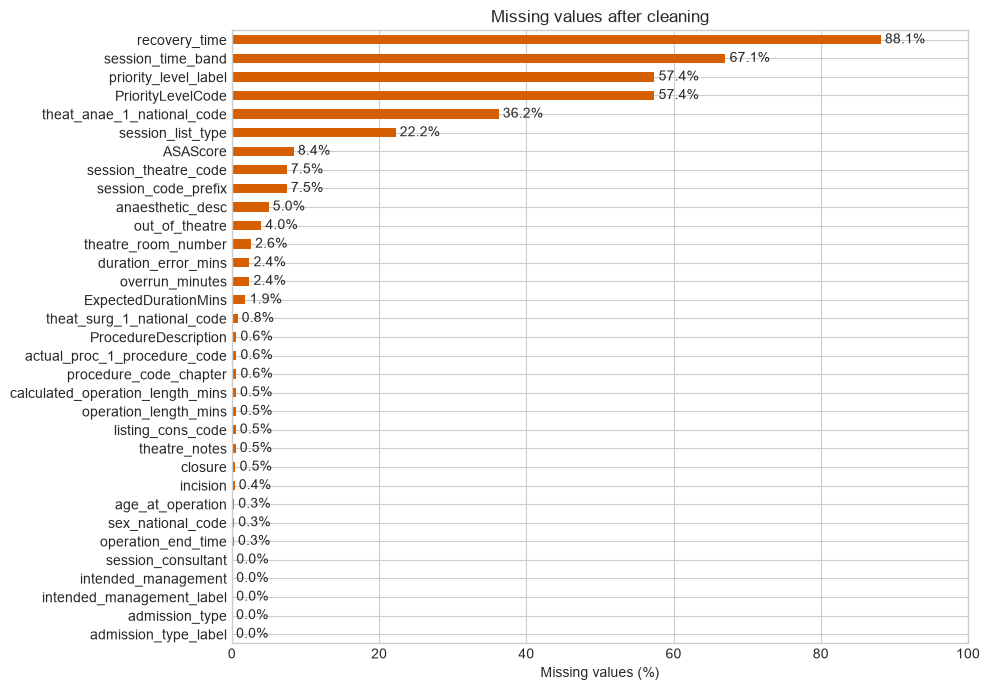

In [108]:
missing_pct_after_cleaning = (analysis_df.isna().mean() * 100).sort_values(ascending=True)
missing_pct_after_cleaning = missing_pct_after_cleaning[missing_pct_after_cleaning > 0]

fig, ax = plt.subplots(figsize=(10, 7))
missing_pct_after_cleaning.plot(kind="barh", ax=ax, color="#D55E00")
ax.set_title("Missing values after cleaning")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set_xlim(0, min(100, missing_pct_after_cleaning.max() + 12))

plt.tight_layout()


**Result interpretation:** The missing-value chart helps decide which columns need extra attention later. At this stage we should not automatically fill all missing values. The correct treatment depends on the final task: reporting, EDA, or modelling. For modelling, the next decision will be whether to drop very incomplete columns, impute missing values, or keep missingness as a separate signal.


## 10. EDA on cleaned data

This section uses `analysis_df`, the cleaned analysis dataset created in Section 9. It includes both relationship tables and visual EDA.


### 10.1 Relationship tables

These tables compare operation length across important clinical and operational categories. They are useful for early pattern-finding before formal modelling. Median is included because operation durations can contain large outliers.


In [109]:
analysis_df.groupby("anaesthetic_desc", dropna=False).agg(
    cases=("operation_length_mins", "size"),
    median_operation_length=("operation_length_mins", "median"),
    mean_operation_length=("operation_length_mins", "mean"),
    median_expected_duration=("ExpectedDurationMins", "median"),
).sort_values("cases", ascending=False)


,cases,median_operation_length,mean_operation_length,median_expected_duration
anaesthetic_desc,,,,
GA,8192,102.00,129.92,90.00
LA (Surgeon),4113,37.00,46.84,60.00
NaN,744,73.00,83.90,60.00
Neuraxial Block,655,73.00,79.68,60.00
No Anaesthetic,460,35.00,39.84,45.00
GA and Regional,307,118.00,132.36,60.00
Sedation,307,46.50,57.33,60.00
Regional Only,140,71.00,88.42,60.00


In [110]:
analysis_df.groupby("TheatreRoom").agg(
    cases=("operation_length_mins", "size"),
    median_operation_length=("operation_length_mins", "median"),
    mean_operation_length=("operation_length_mins", "mean"),
    missing_operation_length=("operation_length_mins", lambda series: series.isna().sum()),
).sort_values("cases", ascending=False).head(15)


,cases,median_operation_length,mean_operation_length,missing_operation_length
TheatreRoom,,,,
BRUNEL TH 05,706,81.00,101.29,7
PLASTIC MINOR 1,651,31.00,35.31,1
IR LAB 1,631,54.00,65.75,3
GYNAE TH 02,621,72.00,76.02,7
IR LAB 2,551,52.00,62.79,5
CATH LAB 05,524,61.00,69.18,3
PLASTIC MINOR 2,523,28.00,34.38,4
BRUNEL TH 03,520,120.50,135.99,4
BRUNEL TH 06,516,116.00,137.57,4


In [111]:
analysis_df.groupby("ProcedureDescription", dropna=False).agg(
    cases=("operation_length_mins", "size"),
    median_operation_length=("operation_length_mins", "median"),
    mean_operation_length=("operation_length_mins", "mean"),
).query("cases >= 20").sort_values("median_operation_length", ascending=False).head(20)


,cases,median_operation_length,mean_operation_length
ProcedureDescription,,,
Unspecified opening of cranium,60,353.50,387.48
Cystoprostatectomy,24,349.00,384.75
Intraoperative fluid monitoring,26,317.50,316.35
Endarterectomy of femoral artery NEC,28,305.00,311.86
Implantation of brain neurostimulator,22,305.00,295.41
Nephroureterectomy NEC,22,262.00,267.55
Revision of total prosthetic replacement of hip joint NEC,35,255.00,259.94
Revision of total prosthetic replacement of knee joint NEC,22,234.00,230.00
Unspecified other excision of right hemicolon,23,227.00,224.57


### 10.2 Visual inspection

Use these plots to understand completeness, distributions, category balance, duration errors, and relationships between important variables.


In [112]:
plt.style.use("seaborn-v0_8-whitegrid")

plot_color = "#2F6F9F"
highlight_color = "#D55E00"
neutral_color = "#6C757D"


### 10.2.1 Missing values

This shows which columns need the most attention before cleaning or modeling.


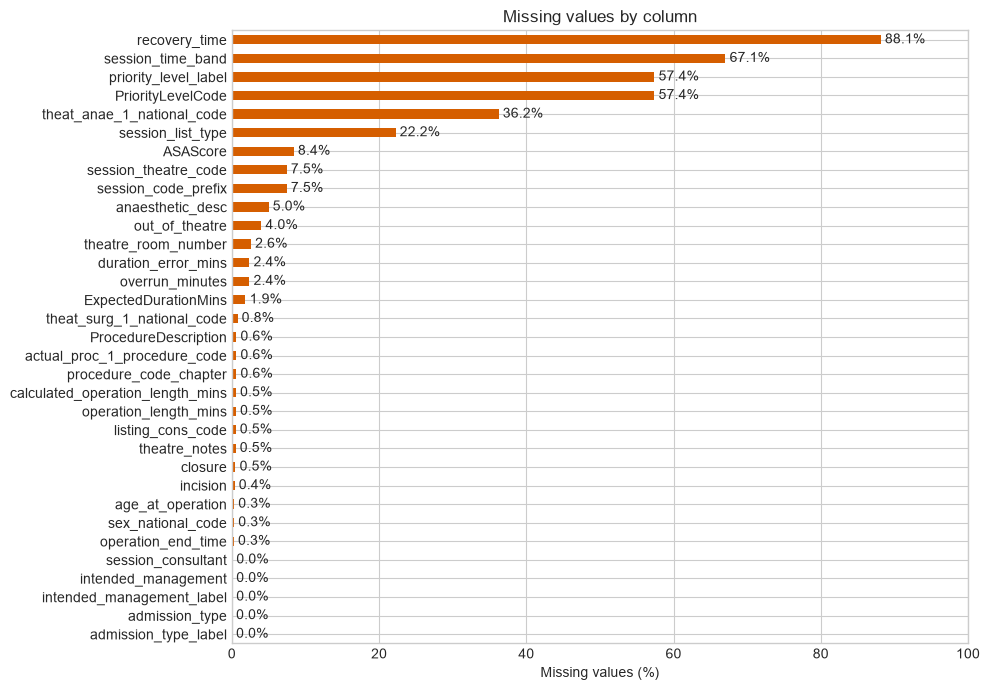

In [113]:
missing_pct = (analysis_df.isna().mean() * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(10, 7))
missing_pct.plot(kind="barh", ax=ax, color=highlight_color)
ax.set_title("Missing values by column")
ax.set_xlabel("Missing values (%)")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.set_xlim(0, min(100, missing_pct.max() + 12))

plt.tight_layout()


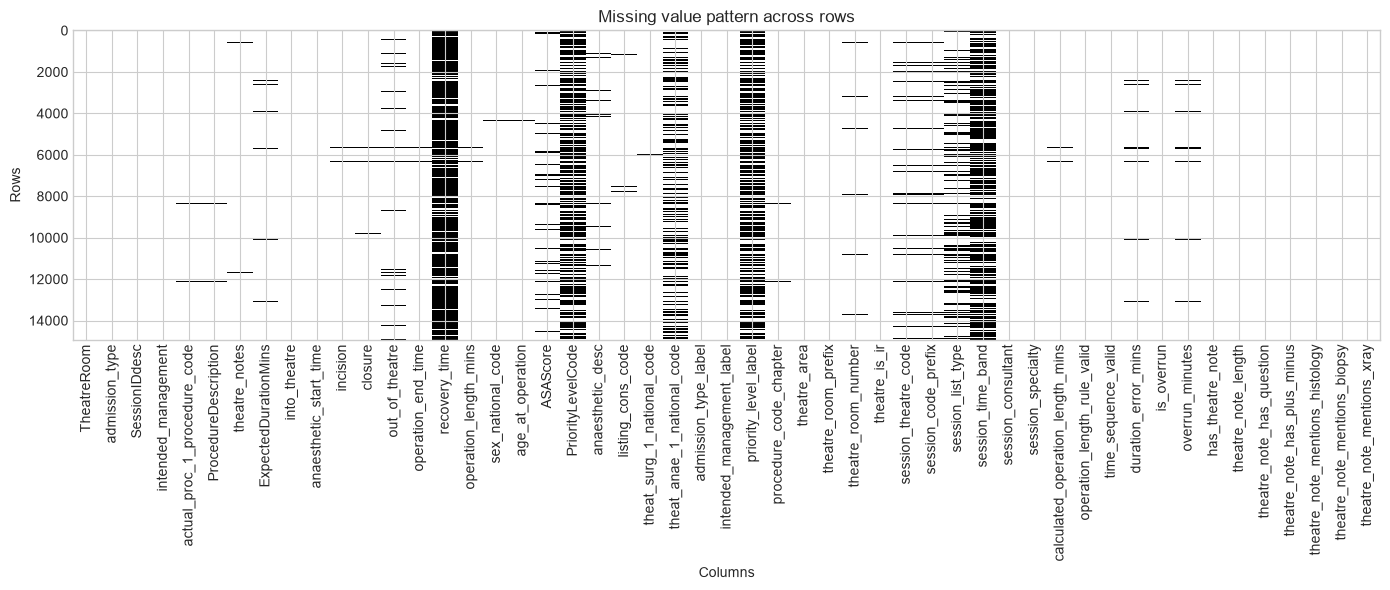

In [114]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.imshow(analysis_df.isna(), aspect="auto", interpolation="nearest", cmap="Greys")
ax.set_title("Missing value pattern across rows")
ax.set_xlabel("Columns")
ax.set_ylabel("Rows")
ax.set_xticks(range(len(analysis_df.columns)))
ax.set_xticklabels(analysis_df.columns, rotation=90)

plt.tight_layout()


### 10.2.2 Numeric distributions

These plots show the shape of important numeric columns and help reveal skew, outliers, and impossible values.


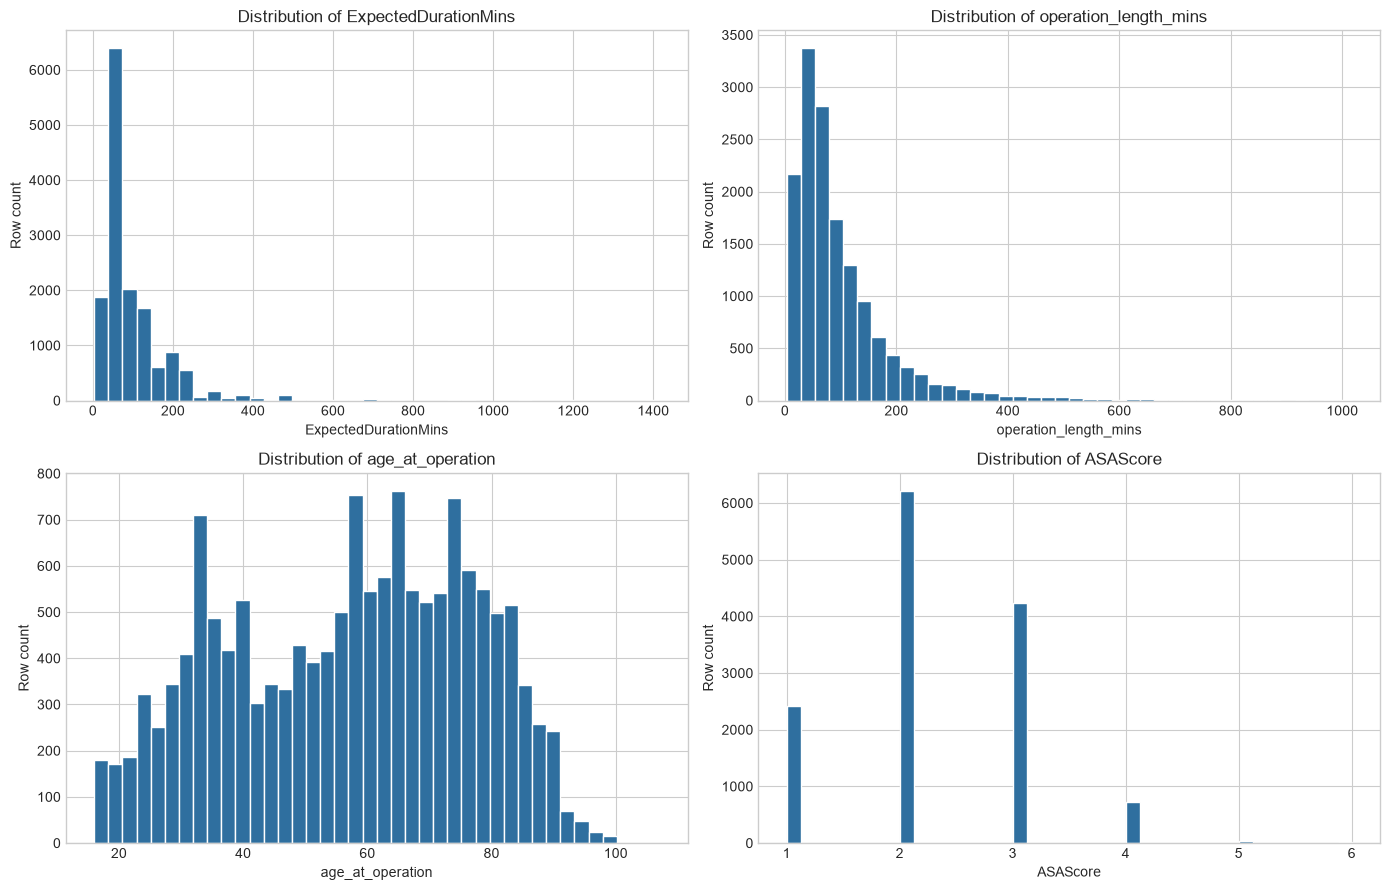

In [115]:
plot_columns = ["ExpectedDurationMins", "operation_length_mins", "age_at_operation", "ASAScore"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, column in zip(axes, plot_columns):
    analysis_df[column].dropna().plot(kind="hist", bins=40, ax=ax, color=plot_color, edgecolor="white")
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Row count")

plt.tight_layout()


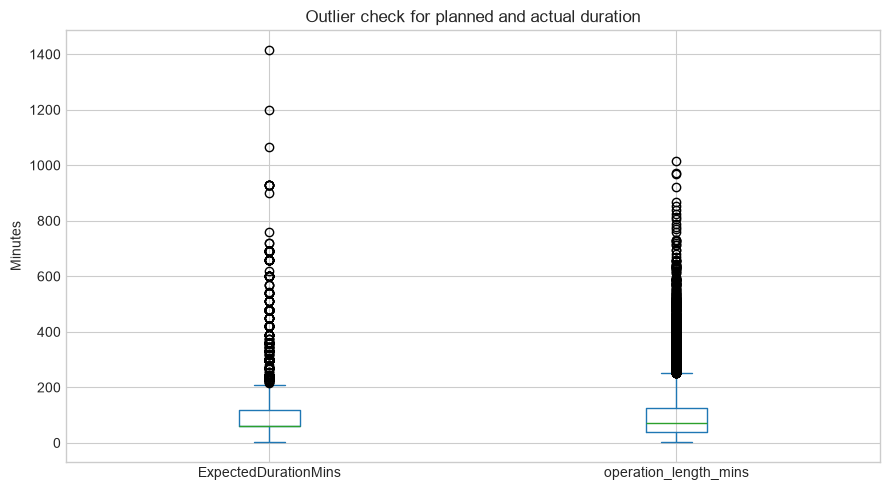

In [116]:
duration_columns = ["ExpectedDurationMins", "operation_length_mins"]

fig, ax = plt.subplots(figsize=(9, 5))
analysis_df[duration_columns].plot(kind="box", ax=ax)
ax.set_title("Outlier check for planned and actual duration")
ax.set_ylabel("Minutes")

plt.tight_layout()


### 10.2.3 Categorical distributions

These plots show the most common rooms, procedures, priority codes, anaesthetic types, and ASA scores.


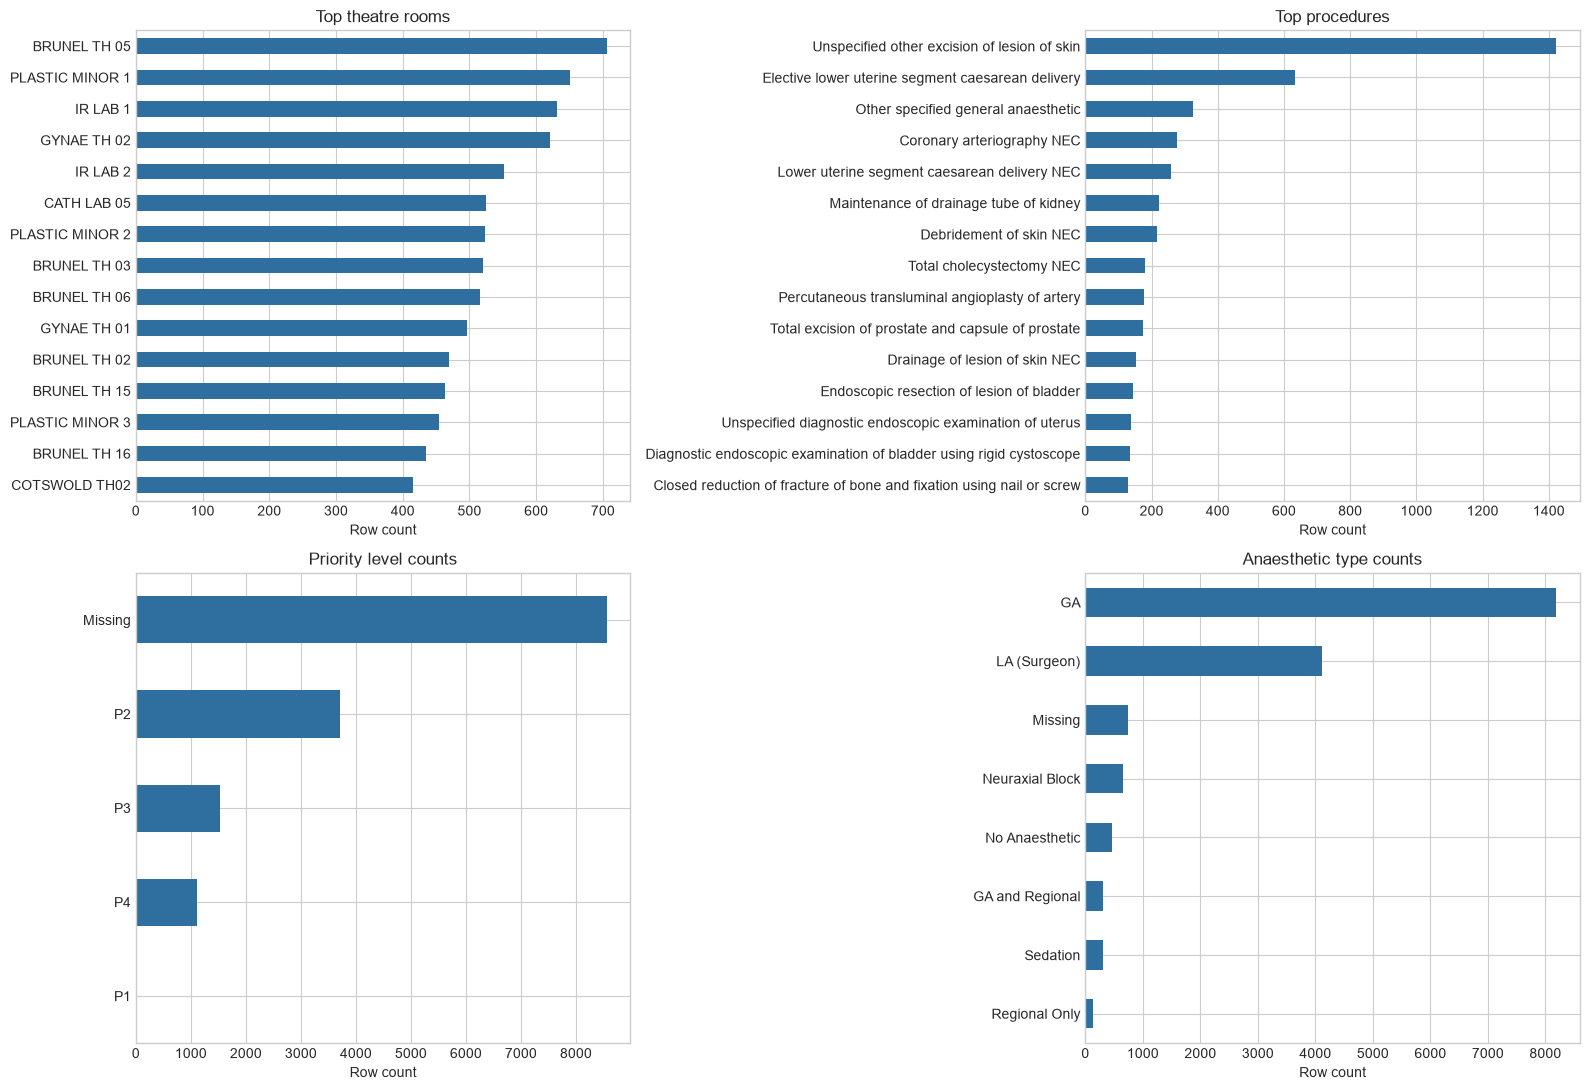

In [117]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
axes = axes.ravel()

category_plots = {
    "Top theatre rooms": analysis_df["TheatreRoom"].value_counts().head(15),
    "Top procedures": analysis_df["ProcedureDescription"].value_counts().head(15),
    "Priority level counts": analysis_df["PriorityLevelCode"].fillna("Missing").value_counts(),
    "Anaesthetic type counts": analysis_df["anaesthetic_desc"].fillna("Missing").value_counts(),
}

for ax, (title, values) in zip(axes, category_plots.items()):
    values.sort_values().plot(kind="barh", ax=ax, color=plot_color)
    ax.set_title(title)
    ax.set_xlabel("Row count")
    ax.set_ylabel("")

plt.tight_layout()


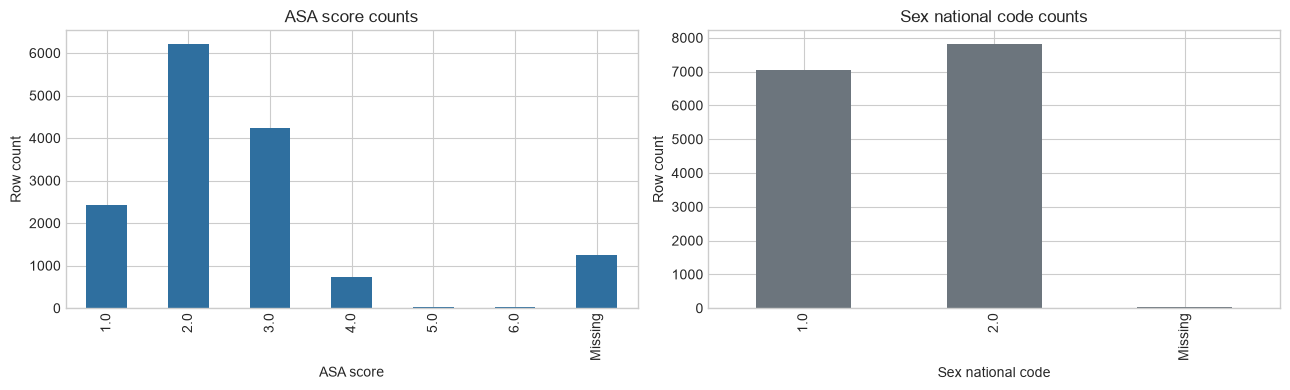

In [118]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

analysis_df["ASAScore"].astype("string").fillna("Missing").value_counts().sort_index().plot(kind="bar", ax=axes[0], color=plot_color)
axes[0].set_title("ASA score counts")
axes[0].set_xlabel("ASA score")
axes[0].set_ylabel("Row count")

analysis_df["sex_national_code"].astype("string").fillna("Missing").value_counts().sort_index().plot(kind="bar", ax=axes[1], color=neutral_color)
axes[1].set_title("Sex national code counts")
axes[1].set_xlabel("Sex national code")
axes[1].set_ylabel("Row count")

plt.tight_layout()


### 10.2.4 Relationships and performance checks

These visuals compare planned duration with actual operation length and show where duration differs by room or anaesthetic type.


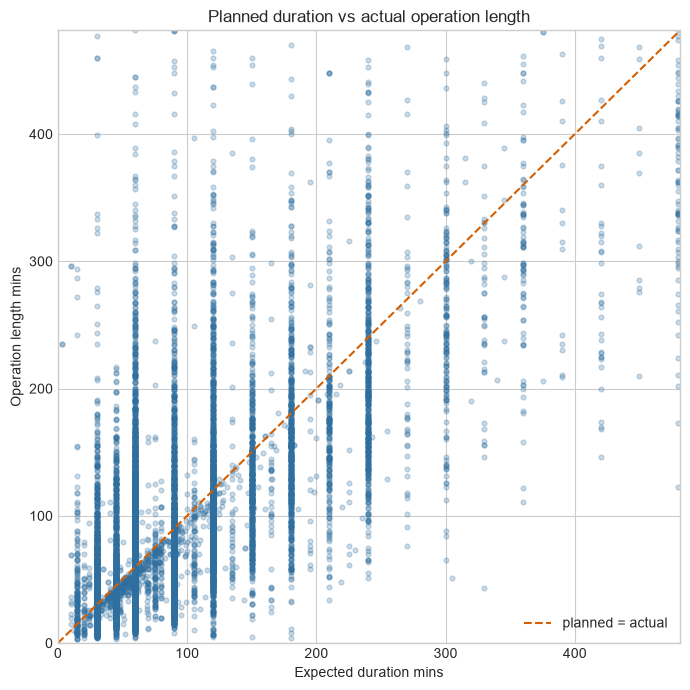

In [119]:
duration_plot_df = analysis_df[["ExpectedDurationMins", "operation_length_mins"]].dropna()

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    duration_plot_df["ExpectedDurationMins"],
    duration_plot_df["operation_length_mins"],
    alpha=0.25,
    s=12,
    color=plot_color,
)

max_duration = duration_plot_df[["ExpectedDurationMins", "operation_length_mins"]].quantile(0.99).max()
ax.plot([0, max_duration], [0, max_duration], color=highlight_color, linestyle="--", label="planned = actual")
ax.set_xlim(0, max_duration)
ax.set_ylim(0, max_duration)
ax.set_title("Planned duration vs actual operation length")
ax.set_xlabel("Expected duration mins")
ax.set_ylabel("Operation length mins")
ax.legend()

plt.tight_layout()


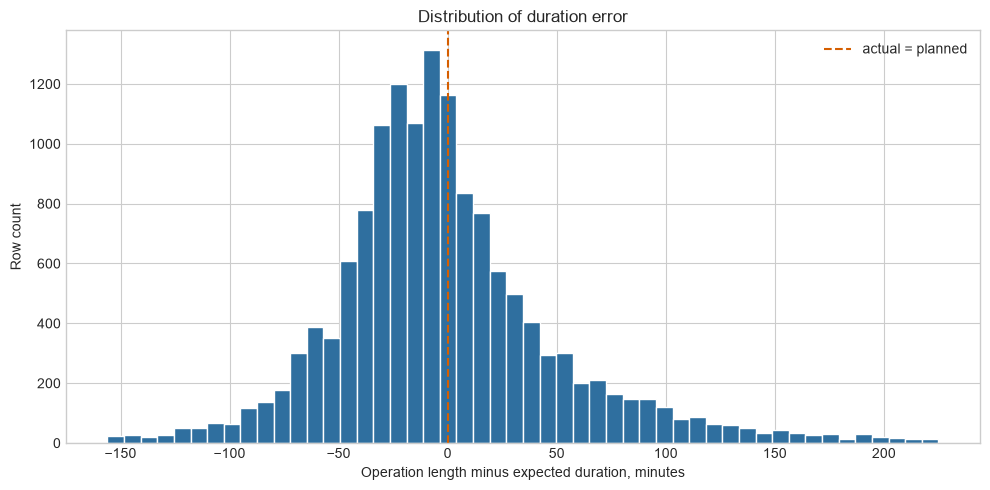

In [120]:
duration_error = analysis_df["operation_length_mins"] - analysis_df["ExpectedDurationMins"]
duration_error_trimmed = duration_error[duration_error.between(duration_error.quantile(0.01), duration_error.quantile(0.99))]

fig, ax = plt.subplots(figsize=(10, 5))
duration_error_trimmed.dropna().plot(kind="hist", bins=50, ax=ax, color=plot_color, edgecolor="white")
ax.axvline(0, color=highlight_color, linestyle="--", label="actual = planned")
ax.set_title("Distribution of duration error")
ax.set_xlabel("Operation length minus expected duration, minutes")
ax.set_ylabel("Row count")
ax.legend()

plt.tight_layout()


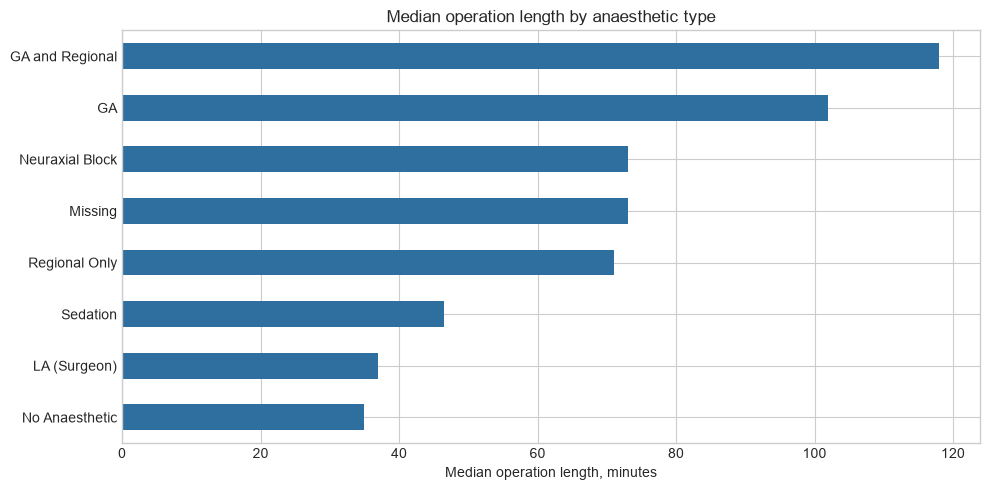

In [121]:
duration_by_anaesthetic = (
    analysis_df.assign(anaesthetic_desc=analysis_df["anaesthetic_desc"].fillna("Missing"))
    .groupby("anaesthetic_desc")["operation_length_mins"]
    .median()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(10, 5))
duration_by_anaesthetic.plot(kind="barh", ax=ax, color=plot_color)
ax.set_title("Median operation length by anaesthetic type")
ax.set_xlabel("Median operation length, minutes")
ax.set_ylabel("")

plt.tight_layout()


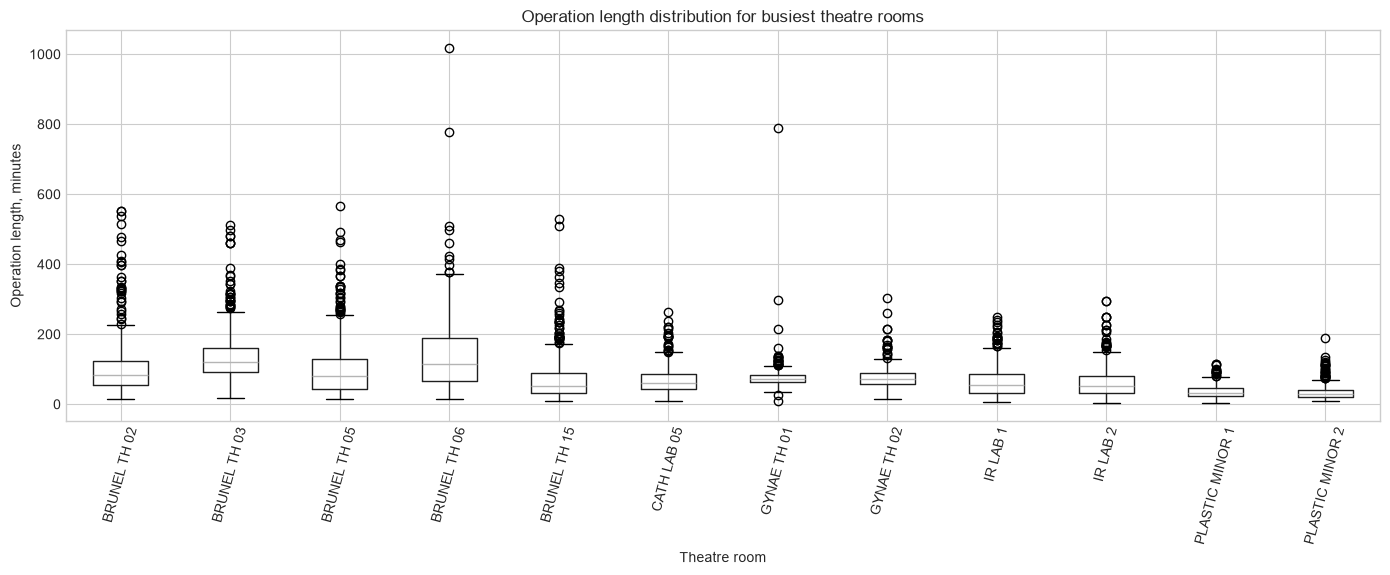

In [122]:
top_rooms = analysis_df["TheatreRoom"].value_counts().head(12).index
room_duration_df = analysis_df[analysis_df["TheatreRoom"].isin(top_rooms)]

fig, ax = plt.subplots(figsize=(14, 6))
room_duration_df.boxplot(column="operation_length_mins", by="TheatreRoom", ax=ax, rot=75)
ax.set_title("Operation length distribution for busiest theatre rooms")
ax.set_xlabel("Theatre room")
ax.set_ylabel("Operation length, minutes")
fig.suptitle("")

plt.tight_layout()


## 11. Initial findings to investigate

- The dataset has 14,918 rows and 24 columns.
- `recovery_time` is mostly missing, so it may not be reliable unless recovery data is optional or captured elsewhere.
- `PriorityLevelCode` and `theat_anae_1_national_code` also have high missingness.
- There are a few exact duplicate rows that should be reviewed before modeling.
- Some duration fields include zeros and very large values, so outlier checks are important.
- Time columns are stored as objects, so they should be converted carefully before time-based feature engineering.
- `theatre_notes` can contain useful information, but it is free text and should be cleaned separately from structured columns.


## 12. Recommended next steps

1. Decide the project target: prediction, cleaning/reporting, delay analysis, theatre utilization, or case-duration modeling.
2. Create a cleaned copy of the dataframe instead of overwriting the raw dataframe.
3. Standardize column names to snake_case.
4. Convert categorical code columns to string/category types.
5. Convert time columns using `pd.to_timedelta` and document how overnight cases should be handled.
6. Decide how to handle missing values column by column.
7. Review duplicate rows and impossible/suspicious duration values before removing anything.


## References

NHS Data Dictionary (2005) *Intended Management*. Available at: https://v2.datadictionary.nhs.uk/data_dictionary/data_field_notes/i/intended_management_de.asp%40shownav%3D1.html (Accessed: 27 July 2026).

NHS Data Dictionary (2014) *Person Stated Gender Code*. Available at: https://archive.datadictionary.nhs.uk/DD%20Release%20November%202014/data_dictionary/attributes/p/person/person_stated_gender_code_de.asp%40shownav%3D1.html (Accessed: 27 July 2026).

NHS Data Dictionary (2024) *ASA Physical Status Classification System Code*. Available at: https://archive.datadictionary.nhs.uk/DD%20Release%20May%202024/attributes/asa_physical_status_classification_system_code.html (Accessed: 27 July 2026).

NHS Data Dictionary (2025) *Method of Admission*. Available at: https://v3.datadictionary.nhs.uk/data_dictionary/attributes/m/meta/method_of_admission_de.asp%40shownav%3D1.html (Accessed: 27 July 2026).

NHS England (n.d.) *National Elective Access Policy*. Available at: https://www.england.nhs.uk/long-read/national-elective-access-policy/ (Accessed: 27 July 2026).

NHS England Digital (n.d.) *Clinical classifications*. Available at: https://digital.nhs.uk/services/terminology-and-classifications/clinical-classifications (Accessed: 27 July 2026).
